# **1. Experimental Design**

*1.1 Objective*

O objetivo deste projeto é desenvolver um modelo de classificação binária capaz de estimar a probabilidade de inadimplência no próximo mês (default.payment.next.month).

Formalmente, buscamos aproximar:

𝑃(𝑌 = 1 ∣ 𝑋)

Onde:

𝑌 ∈ {0,1} representa o evento de default

𝑌 = 1 → cliente inadimplente

𝑌 = 0 → cliente adimplente

𝑋 representa o vetor de variáveis explicativas (limite de crédito, histórico de pagamento, valores de fatura, pagamentos anteriores, etc.)

O modelo deve ser capaz de discriminar clientes com maior risco de inadimplência, permitindo priorização e melhor tomada de decisão no processo de concessão de crédito.

*1.2 Data Splitting Strategy*

Como o dataset não possui informação temporal explícita, será adotada a seguinte estratégia de separação:

**Holdout 70% / 30%**

    70% para treino

    30% para teste final

**Divisão estratificada com base na variável alvo**

A estratificação é necessária devido ao desbalanceamento da base (inadimplentes representam aproximadamente 22% do total).
Ela garante que a proporção da classe seja mantida tanto no conjunto de treino quanto no conjunto de teste.

*O conjunto de teste permanecerá isolado até a etapa final de avaliação, evitando vazamento de informação.*

*1.3 Validation Strategy*

Dentro do conjunto de treino será utilizada validação cruzada estratificada (Stratified K-Fold, k = 5) com os seguintes objetivos:

    Reduzir a variância na estimativa de performance

    Comparar modelos de forma mais robusta

    Minimizar risco de overfitting

A estratificação também será mantida na validação cruzada para preservar a proporção da classe em cada fold.

*1.4 Evaluation Metrics*

Devido ao desbalanceamento da base, acurácia não será utilizada como métrica principal, pois pode gerar interpretações enganosas.

As métricas escolhidas são:

🎯 **Primary Metric**
ROC-AUC

    Mede a capacidade discriminatória do modelo independentemente do threshold

    Avalia o quão bem o modelo separa as classes

    Amplamente utilizada em modelos de risco de crédito

💼 **Secondary Business Metric**
Recall (Classe 1 – Inadimplentes)

    Mede a proporção de inadimplentes corretamente identificados

    Alta relevância para mitigação de perdas

    Reduz risco de conceder crédito a clientes com alta probabilidade de default

📊 **Complementary Metrics**

Precision (Classe 1)

    Avalia a proporção de previsões positivas que realmente são inadimplentes

F1-Score

    Média harmônica entre precision e recall

Matriz de Confusão

    Permite visualizar erros de classificação e o trade-off entre falso positivo e falso negativo

Essas métricas permitem avaliar o equilíbrio entre capturar inadimplentes e evitar a rejeição indevida de bons pagadores.

*1.5 Baseline Models*

Antes da implementação de modelos mais complexos, serão estabelecidos dois benchmarks iniciais:

1️⃣ Dummy Classifier

    Modelo que sempre prevê a classe majoritária

    Não aprende padrões

    Serve como referência mínima de desempenho

O objetivo é verificar se o modelo proposto realmente aprende algo além de uma estratégia trivial.

2️⃣ Logistic Regression

Modelo linear amplamente utilizado em crédito devido à sua:

    Interpretabilidade

    Estabilidade

    Simplicidade

Qualquer modelo mais complexo deverá superar consistentemente a regressão logística para justificar aumento de complexidade.

*1.6 Success Criteria*

O modelo será considerado satisfatório se:

    Superar o desempenho do Dummy Classifier

    Apresentar ROC-AUC superior ao baseline logístico

    Demonstrar melhoria no recall da classe inadimplente sem perda significativa de precisão

    Apresentar estabilidade entre validação cruzada e teste final

*1.7. Business Hypotheses*

Objetivo

Além da construção de um modelo preditivo, este projeto busca investigar fatores potencialmente associados ao risco de inadimplência.

Com base em conceitos amplamente utilizados em análise de crédito, foram formuladas as seguintes hipóteses de negócio.

**Hipótese 1 — Atrasos recentes aumentam o risco**

Clientes com atrasos mais recentes apresentam maior probabilidade de inadimplência do que aqueles cujo histórico de atraso é mais antigo.

**Justificativa**

Em operações de crédito, o comportamento recente costuma ser um dos principais indicadores de deterioração financeira.

**Variáveis relacionadas**

    PAY_0
    PAY_2
    PAY_3
    Max Delay
    Avg Delay

**Hipótese 2 — Baixo esforço de pagamento aumenta risco**

Clientes que pagam sistematicamente apenas pequena parcela de suas faturas tendem a apresentar maior risco de default.

**Justificativa**

O comportamento de pagamento pode refletir dificuldades financeiras antes da inadimplência formal.

**Hipótese 3 — Capacidade financeira mitiga risco**

Clientes com maior limite de crédito tendem a apresentar menor risco de inadimplência, controlando-se demais fatores comportamentais.

**Justificativa**

Limites mais elevados costumam estar associados a perfis de menor risco segundo políticas tradicionais de crédito.

# **2. Setup**

Nesta seção serão realizadas as configurações iniciais do ambiente de trabalho, incluindo:

- Importação das bibliotecas necessárias
- Definição de parâmetros globais
- Configuração de visualização
- Garantia de reprodutibilidade

O objetivo é preparar o ambiente de forma controlada antes do carregamento da base de dados.

In [106]:
# Manipulação de dados
import pandas as pd
import numpy as np
import math

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Modelagem e validação
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Métricas
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    precision_recall_curve,
    f1_score
)

## 2.1 Reproducibility

Para garantir consistência nos resultados, será definido um `random_state` fixo.

Isso assegura que divisões de dados e algoritmos estocásticos produzam resultados reproduzíveis.

In [2]:
random_state = 42

## 2.2 Visualization Configuration

Serão definidas configurações padrão para visualização, garantindo consistência estética nos gráficos ao longo do projeto.

In [3]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

## 2.3 Warning Management

Avisos desnecessários serão suprimidos para manter a saída do notebook mais limpa.

In [4]:
import warnings
warnings.filterwarnings("ignore")

# **3. Data Loading**

Nesta seção será realizado o carregamento da base de dados e uma inspeção inicial para garantir integridade, consistência e adequação ao plano experimental definido anteriormente.

Serão verificadas:

- Dimensão da base
- Tipos de dados
- Valores nulos
- Duplicados
- Distribuição da variável alvo

In [5]:
# Carregamento do dataset
df = pd.read_excel(
    "default of credit card clients.xls",
    header=1
)

# Visualização inicial
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


Como o dataset se apresentava com um cabeçalho adicional, já apliquei o header igual a 1 para remover este cabeçalho e ficar com o dataset de acordo.

Vou remover a coluna ID pois esta não traz nenhuma informação relevante ao objetivo.

In [6]:
# Removendo coluna identificadora
df.drop(columns=["ID"], inplace=True)

Apenas para padronizar e facilitar a visualização, vou deixar todas as colunas com nomes em letra minúscula. Isto não só facilita a visualização como também ajuda na hora de referenciar as colunas.

In [7]:
# Padronizando nomes das colunas
df.columns = df.columns.str.lower()

df.head()

,limit_bal,sex,education,marriage,age,pay_0,pay_2,pay_3,pay_4,pay_5,...,bill_amt4,bill_amt5,bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,default payment next month
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


Dataset já carregado e com os primeiros ajustes realizados.

# **4. Initial Data Inspection**

## 4.1 Dataset Overview

In [8]:
# Informações gerais
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   limit_bal                   30000 non-null  int64
 1   sex                         30000 non-null  int64
 2   education                   30000 non-null  int64
 3   marriage                    30000 non-null  int64
 4   age                         30000 non-null  int64
 5   pay_0                       30000 non-null  int64
 6   pay_2                       30000 non-null  int64
 7   pay_3                       30000 non-null  int64
 8   pay_4                       30000 non-null  int64
 9   pay_5                       30000 non-null  int64
 10  pay_6                       30000 non-null  int64
 11  bill_amt1                   30000 non-null  int64
 12  bill_amt2                   30000 non-null  int64
 13  bill_amt3                   30000 non-null  int64
 14  bill_a

In [9]:
df.nunique().sort_values(ascending=False)

bill_amt1                     22723
bill_amt2                     22346
bill_amt3                     22026
bill_amt4                     21548
bill_amt5                     21010
bill_amt6                     20604
pay_amt1                       7943
pay_amt2                       7899
pay_amt3                       7518
pay_amt6                       6939
pay_amt4                       6937
pay_amt5                       6897
limit_bal                        81
age                              56
pay_2                            11
pay_0                            11
pay_4                            11
pay_3                            11
pay_5                            10
pay_6                            10
education                         7
marriage                          4
sex                               2
default payment next month        2
dtype: int64

In [10]:
print("Número de linhas:", df.shape[0])
print("Número de colunas:", df.shape[1])

Número de linhas: 30000
Número de colunas: 24


Verificando o shape, encontramos 30 mil registros e 24 variáveis, sendo 1 target e 23 explicativas.
Além disto, todas as variáveis apresentam formato numérico, o que pode facilitar na adequação a alguns modelos que provavelmente irei testar.
Cabe destacar, entretanto, que apesar de todas estarem em formato numérico, conforme constam as documentações do dataset, as variáveis "sex", "education" e "marriage" são variáveis categóricas.

## 4.2 Missing Values

In [11]:
df.isnull().sum()

limit_bal                     0
sex                           0
education                     0
marriage                      0
age                           0
pay_0                         0
pay_2                         0
pay_3                         0
pay_4                         0
pay_5                         0
pay_6                         0
bill_amt1                     0
bill_amt2                     0
bill_amt3                     0
bill_amt4                     0
bill_amt5                     0
bill_amt6                     0
pay_amt1                      0
pay_amt2                      0
pay_amt3                      0
pay_amt4                      0
pay_amt5                      0
pay_amt6                      0
default payment next month    0
dtype: int64

Conforme destacado, não possuímos valores missing.

## 4.3 Duplicate Records

In [12]:
df.duplicated().sum()

np.int64(35)

Também não temos dados duplicados.

## 4.4 Target Distribution

In [13]:
target_counts = df["default payment next month"].value_counts()
target_ratio = df["default payment next month"].value_counts(normalize=True)

print("Distribuição absoluta:")
print(target_counts)

print("\nDistribuição percentual:")
print(target_ratio)

Distribuição absoluta:
default payment next month
0    23364
1     6636
Name: count, dtype: int64

Distribuição percentual:
default payment next month
0    0.7788
1    0.2212
Name: proportion, dtype: float64


A verificação da variável alvo permite confirmar o desbalanceamento da base, justificando o uso de:

- Estratificação na divisão dos dados
- Métricas além da acurácia

## 4.5 Descriptive Statistics (Numerical Features)

In [14]:
# Estatísticas descritivas
df.describe()

,limit_bal,sex,education,marriage,age,pay_0,pay_2,pay_3,pay_4,pay_5,...,bill_amt4,bill_amt5,bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


## 4.6 Categorical Variables Overview

In [15]:
# Distribuição de sex
df["sex"].value_counts()

sex
2    18112
1    11888
Name: count, dtype: int64

In [16]:
# Percentual de homens e mulheres
df["sex"].value_counts(normalize = True)

sex
2    0.603733
1    0.396267
Name: proportion, dtype: float64

Mais de 60% da nossa base diz respeito a transações cujo realizante foi uma mulher.

In [17]:
# Distribuição de education
df["education"].value_counts()

education
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64

Segundo a documentação oficial do dataset, apenas 4 classes são reconhecidas na variável education. Desta forma, iremos avaliar a possibilidade de exclusão dessas linhas, uma vez que pode ser um registro inconfiável dentro do dataset.

In [18]:
# Distribuição de marriage
df["marriage"].value_counts()

marriage
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64

Da mesma forma que o anterior, existem mais classes na variável marriage do que a documentação indica. Precisarei decidir o que fazer com essas informações de zero.

Para tomar a decisão, iniciarei verificando a proporção dessas variáveis.

In [19]:
df["education"].value_counts(normalize=True)

education
2    0.467667
1    0.352833
3    0.163900
5    0.009333
4    0.004100
6    0.001700
0    0.000467
Name: proportion, dtype: float64

Para a variável education, as categorias não documentadas (0, 5 e 6) somam:
0.93% + 0.17% + 0.04% ≈ 1.14%

In [20]:
df["marriage"].value_counts(normalize=True)

marriage
2    0.532133
1    0.455300
3    0.010767
0    0.001800
Name: proportion, dtype: float64

Para a variável marriage, a categoria não documentada representa 0.18% do dataset.

# **5. Data Cleaning**

Na etapa de inspeção inicial foram identificadas inconsistências nas variáveis `education` e `marriage`, que apresentavam categorias não documentadas na fonte original do dataset.

Como essas categorias representavam aproximadamente 1,14% e 0,18% dos dados, respectivamente, optou-se por reclassificá-las na categoria "Others", evitando perda de informação e reduzindo ruído estatístico.

In [21]:
# Tratamento das categorias inconsistentes
# EDUCATION: 0, 5 e 6 serão agrupados como 4 (Others)
df["education"] = df["education"].replace({0:4, 5:4, 6:4})

# MARRIAGE: 0 será agrupado como 3 (Others)
df["marriage"] = df["marriage"].replace({0:3})

In [22]:
df["education"].value_counts(normalize=True)

education
2    0.467667
1    0.352833
3    0.163900
4    0.015600
Name: proportion, dtype: float64

In [23]:
df["marriage"].value_counts(normalize=True)

marriage
2    0.532133
1    0.455300
3    0.012567
Name: proportion, dtype: float64

Como podemos observar, ambas variáveis foram categorizadas corretamente, aumentando a proporção de 'others'.

As verificações de valores nulos e duplicatas foram realizadas na etapa de inspeção inicial e não houve alterações estruturais que justificassem nova validação.

Após o tratamento:

- As categorias inconsistentes foram reclassificadas.
- Não foram identificados valores nulos.
- Não foram identificadas duplicatas relevantes.
- O dataset encontra-se consistente para a etapa de Análise Exploratória (EDA).

Com isso, os dados estão estruturalmente adequados para análises estatísticas
e preparação para modelagem.

# **6. Exploratory Data Analysis (EDA)**

Qual será meu objetivo dentro do EDA aqui? Como já fiz a verificação estrutural em itens iniciais de inspeção de dados, vou focalizar na pergunta pertinente de negócio: **O que diferencia quem dá default de quem não dá?**

Como itens secundários também irei buscar responder: 
- Quais variáveis parecem mais relevantes;
- Existem padrões claros?
- Existem relações fortes?
- Há multicolinearidade?

Transformarei meu EDA em um passo de análise estratégica.

## 6.1 Target Analysis

### Objective
Aqui tenho como objetivo compreender a distribuição da variável alvo e avaliar o potencial desequilíbrio de classes.

Este passo é extremamente essencial, pois:
- Impacta a seleção do modelo
- Influencia as métricas de avaliação
- Pode exigir estratégias de reamostragem.

Variável alvo: `default payment next month`

In [24]:
target = "default payment next month"

# Distribution
df[target].value_counts()

default payment next month
0    23364
1     6636
Name: count, dtype: int64

In [25]:
# Proportion
df[target].value_counts(normalize=True)

default payment next month
0    0.7788
1    0.2212
Name: proportion, dtype: float64

Como já tínhamos visto anteriormente, possuímos 6636 registros inadimplentes, representando cerca de 22% da base

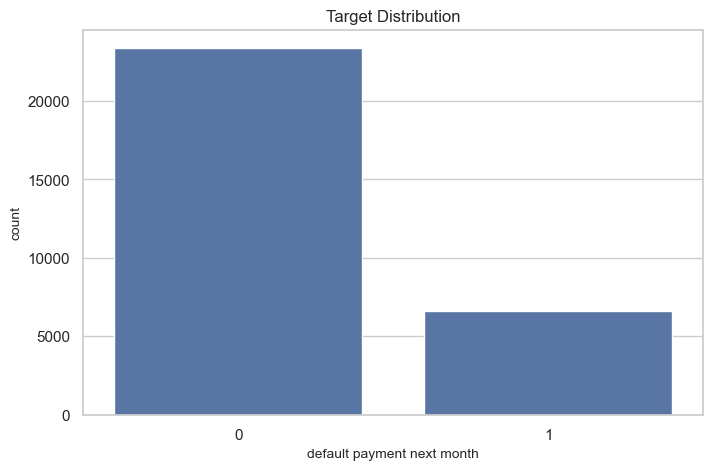

In [26]:
# Plot
sns.countplot(x=target, data=df)
plt.title("Target Distribution")
plt.show()

### Insight de Negócio

O conjunto de dados apresenta um desbalanceamento moderado entre as classes:

- 77,9% Não inadimplentes
- 22,1% Inadimplentes

Esse cenário confirma a decisão previamente estabelecida na seção de *Experimental Design*, na qual foi definida a priorização de métricas além da acurácia, com especial atenção às métricas sensíveis à classe minoritária (inadimplência).

Embora o desbalanceamento não seja extremo, torna-se essencial monitorar cuidadosamente métricas como *recall*, *precision* e *F1-score* da classe positiva, uma vez que o erro na identificação de clientes inadimplentes possui impacto direto na gestão de risco de crédito.

## 6.2 Univariate Analysis

### Objective
Aqui o objetivo será focalizado em entender a distribuição das principais variáveis numéricas e categóricas.

Isto ajuda a detectar:
- Valores discrepantes (Outliers)
- Assimetria (Skewness)
- Valores extremos (Extreme values)
- Potenciais oportunidades de engenharia de recursos (feature engineering)

### 6.2.1 Numerical Variables

Variáveis numéricas que serão analisadas:

- Credit limit (`limit_bal`)
- Age (`age`)
- Bill amounts (`bill_amt1` to `bill_amt6`)
- Payment amounts (`pay_amt1` to `pay_amt6`)

### Summary Statistics

In [27]:
numerical_cols = [
    "limit_bal", "age",
    "bill_amt1","bill_amt2","bill_amt3","bill_amt4","bill_amt5","bill_amt6",
    "pay_amt1","pay_amt2","pay_amt3","pay_amt4","pay_amt5","pay_amt6"
]

df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
limit_bal,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
age,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
bill_amt1,30000.0,51223.330900,73635.860576,-165580.0,3558.75,22381.5,67091.00,964511.0
bill_amt2,30000.0,49179.075167,71173.768783,-69777.0,2984.75,21200.0,64006.25,983931.0
bill_amt3,30000.0,47013.154800,69349.387427,-157264.0,2666.25,20088.5,60164.75,1664089.0
bill_amt4,30000.0,43262.948967,64332.856134,-170000.0,2326.75,19052.0,54506.00,891586.0
bill_amt5,30000.0,40311.400967,60797.155770,-81334.0,1763.00,18104.5,50190.50,927171.0
bill_amt6,30000.0,38871.760400,59554.107537,-339603.0,1256.00,17071.0,49198.25,961664.0
pay_amt1,30000.0,5663.580500,16563.280354,0.0,1000.00,2100.0,5006.00,873552.0
pay_amt2,30000.0,5921.163500,23040.870402,0.0,833.00,2009.0,5000.00,1684259.0


Sobre a variável de limite de crédito (`limit_bal`), destacam-se alguns pontos relevantes:

- A média (~167k) é superior à mediana (140k), indicando uma distribuição assimétrica à direita, característica comum em dados financeiros;

- Observa-se a presença de clientes com limites significativamente elevados (máximo de 1.000.000), o que, combinado a um desvio padrão elevado (~129k), evidencia alta dispersão dos dados;

- Esse comportamento sugere uma base heterogênea, composta por perfis distintos de clientes em termos de exposição ao crédito.

### Distribution Plots

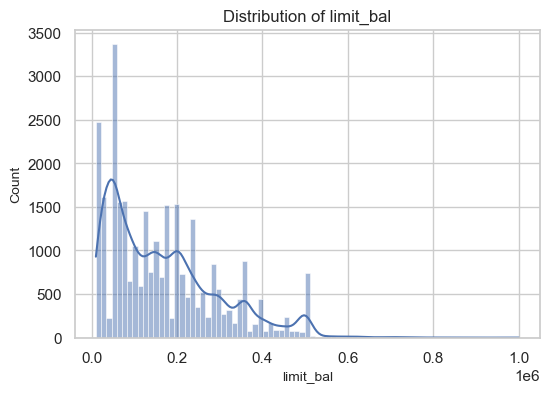

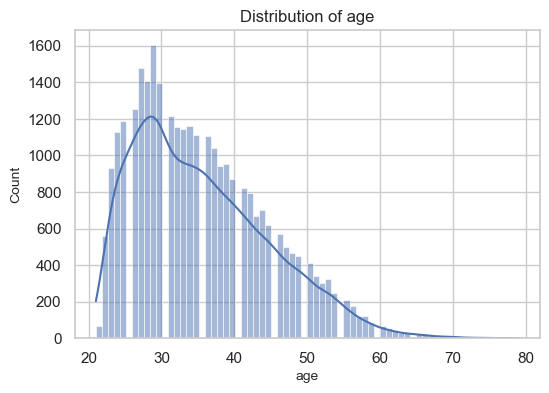

In [28]:
for col in ["limit_bal", "age"]:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

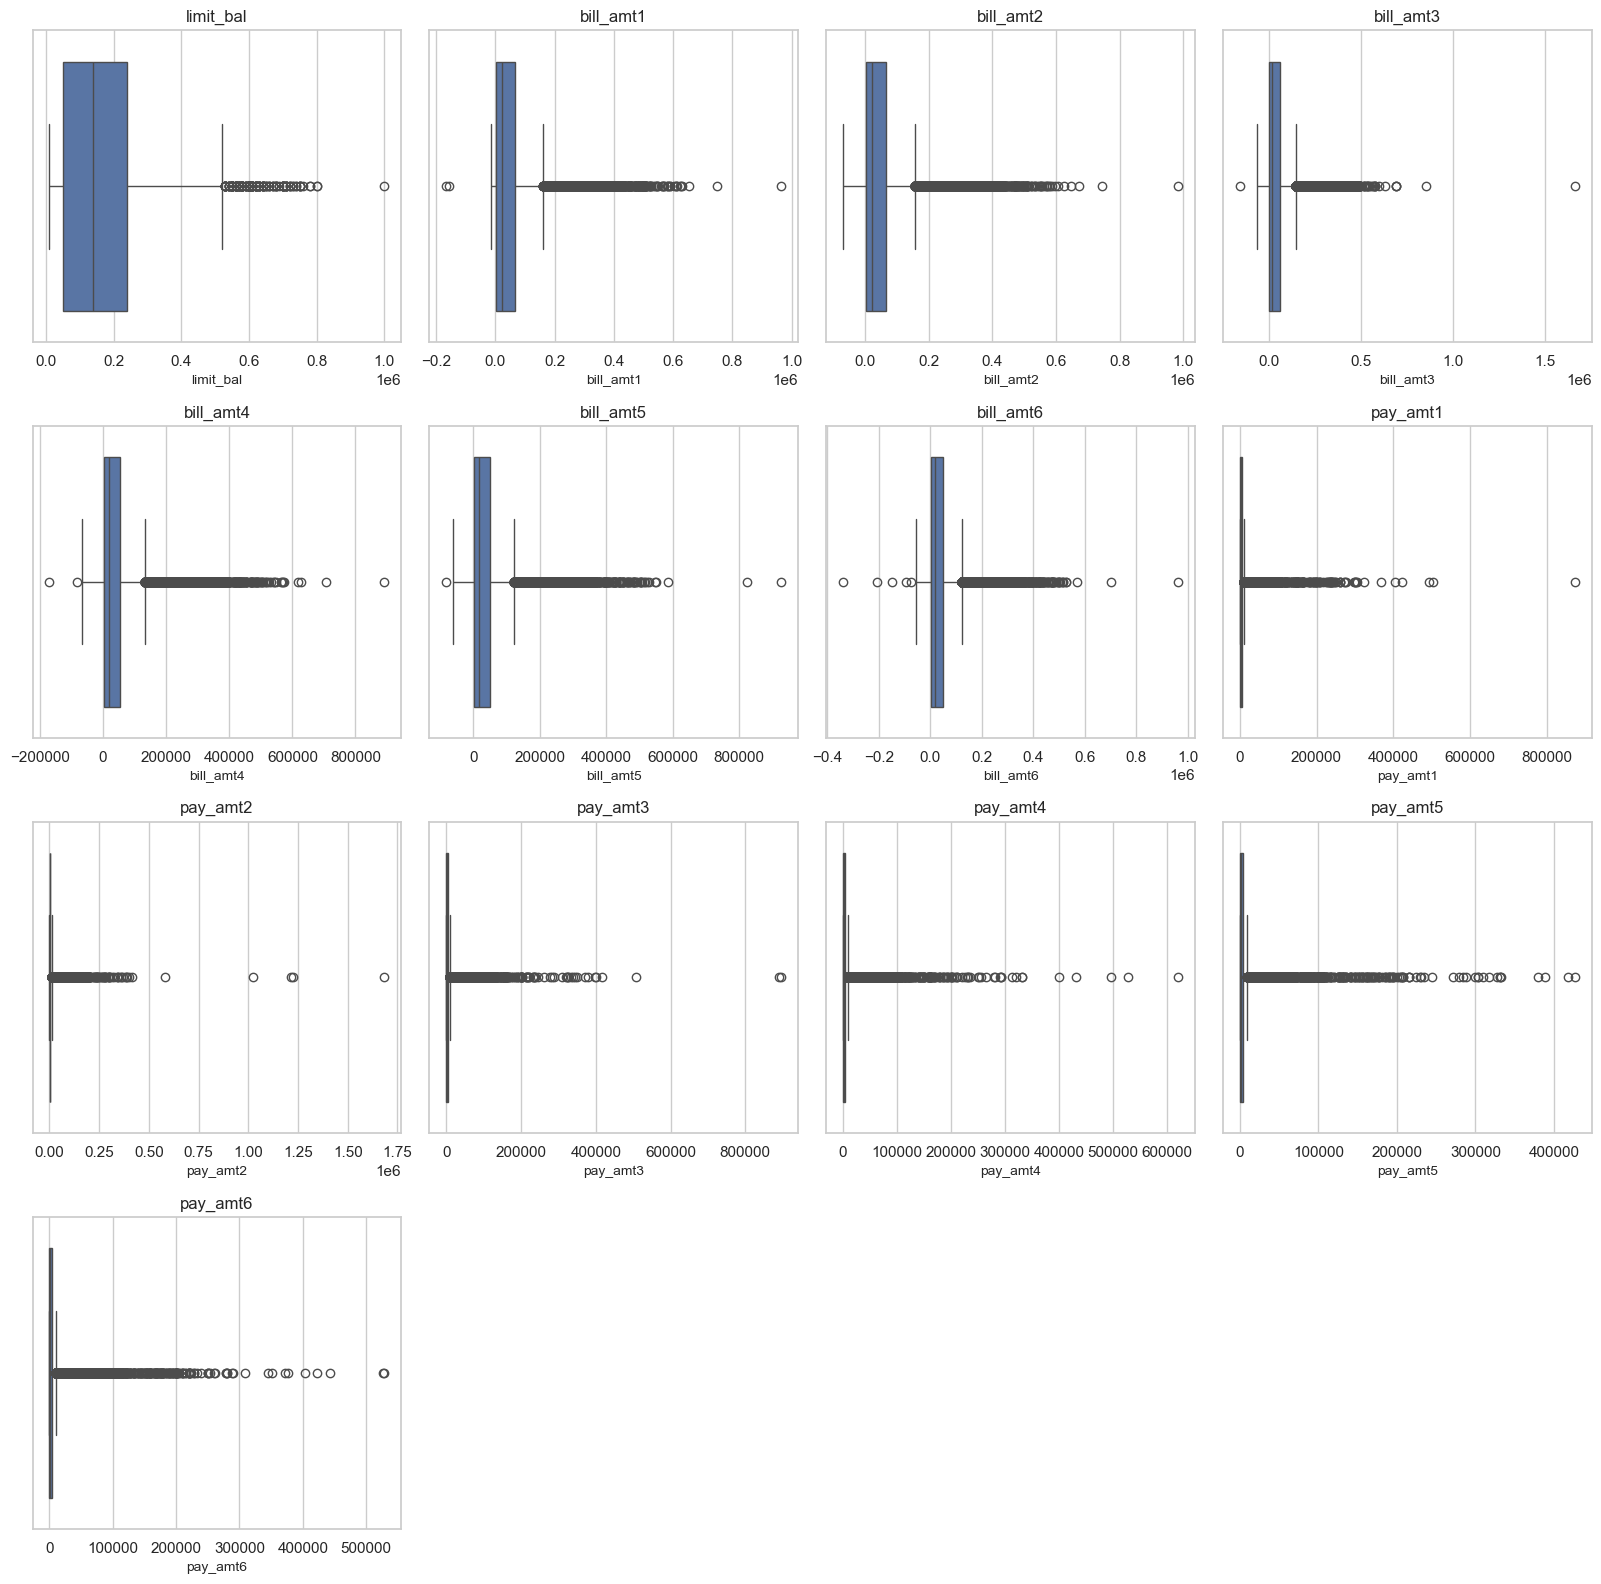

In [29]:
cols = [
    "limit_bal",
    "bill_amt1", "bill_amt2", "bill_amt3", "bill_amt4", "bill_amt5", "bill_amt6",
    "pay_amt1", "pay_amt2", "pay_amt3", "pay_amt4", "pay_amt5", "pay_amt6"
]

n_cols = 4  # número de gráficos por linha
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)

# Remove gráficos vazios (caso sobrem espaços)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Principais Insights das Estatísticas Descritivas

- O limite de crédito (`limit_bal`) apresenta uma distribuição assimétrica à direita, com presença relevante de clientes com alta exposição ao crédito.

- A distribuição de idade é relativamente equilibrada, concentrada em indivíduos em idade economicamente ativa.

- As variáveis de valor de fatura (`bill_amt*`) apresentam alta variabilidade e distribuições com caudas pesadas, indicando comportamento financeiro heterogêneo.

- Valores negativos nas faturas sugerem a ocorrência de créditos ou pagamentos acima do valor devido, e não necessariamente inconsistências nos dados.

- Os valores de pagamento (`pay_amt*`) são altamente assimétricos, com predominância de pagamentos de menor valor e uma pequena parcela de clientes realizando pagamentos significativamente elevados.

- A comparação entre valores de fatura e valores pagos sugere um padrão recorrente de pagamento parcial, o que pode indicar aumento do risco de crédito.

- A elevada variância nas variáveis financeiras indica a necessidade de aplicação de técnicas de escalonamento antes da etapa de modelagem.

## 6.3 Análise Bivariada

### Objetivo

Identificar quais variáveis diferenciam efetivamente os inadimplentes dos não inadimplentes.

Esta etapa visa:

- Detectar variáveis com forte poder discriminatório
- Identificar padrões comportamentais associados à inadimplência
- Gerar insights relacionados ao risco
- Apoiar a seleção de variáveis e as decisões de modelagem

### 6.3.1 Payment Behavior (pay_0 to pay_6)

As variáveis de status de pagamento representam o histórico recente de inadimplência do cliente e são, teoricamente, os principais preditores de default.

A análise busca validar essa hipótese.

In [30]:
pay_cols = ["pay_0","pay_2","pay_3","pay_4","pay_5","pay_6"]

for col in pay_cols:
    print(f"\n{col}")
    display(pd.crosstab(df[col], df["default payment next month"], normalize="index"))


pay_0


default payment next month,0,1
pay_0,,
-2,0.867706,0.132294
-1,0.832219,0.167781
0,0.871887,0.128113
1,0.660521,0.339479
2,0.308586,0.691414
3,0.242236,0.757764
4,0.315789,0.684211
5,0.500000,0.500000
6,0.454545,0.545455



pay_2


default payment next month,0,1
pay_2,,
-2,0.817292,0.182708
-1,0.840331,0.159669
0,0.840877,0.159123
1,0.821429,0.178571
2,0.443850,0.556150
3,0.383436,0.616564
4,0.494949,0.505051
5,0.400000,0.600000
6,0.250000,0.750000



pay_3


...

default payment next month,0,1
pay_4,,
-2,0.807498,0.192502
-1,0.841041,0.158959
0,0.816712,0.183288
1,0.500000,0.500000
2,0.476733,0.523267
3,0.388889,0.611111
4,0.333333,0.666667
5,0.485714,0.514286
6,0.600000,0.400000



pay_5


default payment next month,0,1
pay_5,,
-2,0.803124,0.196876
-1,0.838057,0.161943
0,0.811471,0.188529
2,0.458111,0.541889
3,0.365169,0.634831
4,0.392857,0.607143
5,0.411765,0.588235
6,0.250000,0.750000
7,0.172414,0.827586



pay_6


default payment next month,0,1
pay_6,,
-2,0.799591,0.200409
-1,0.830139,0.169861
0,0.811556,0.188444
2,0.493492,0.506508
3,0.358696,0.641304
4,0.367347,0.632653
5,0.461538,0.538462
6,0.263158,0.736842
7,0.173913,0.826087


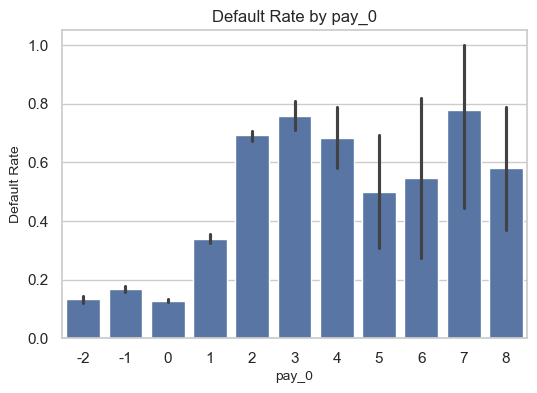

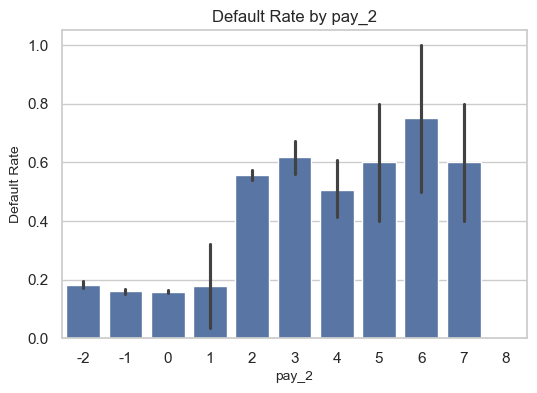

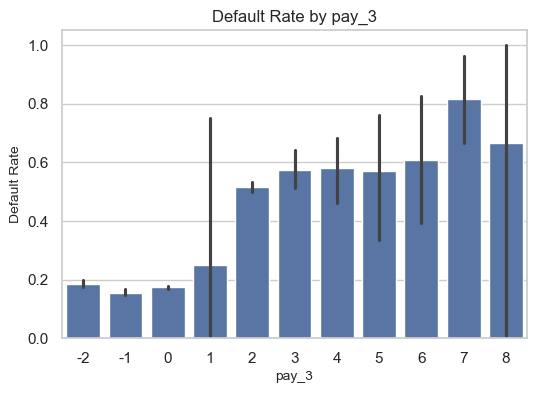

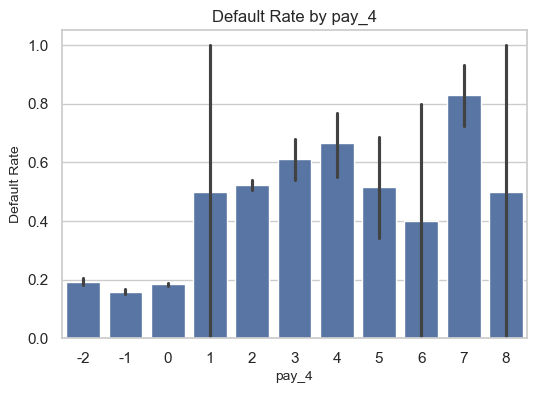

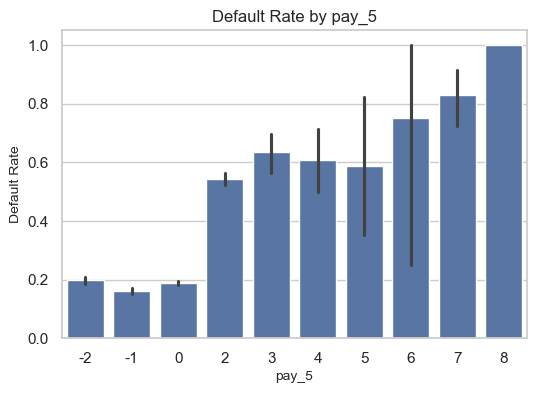

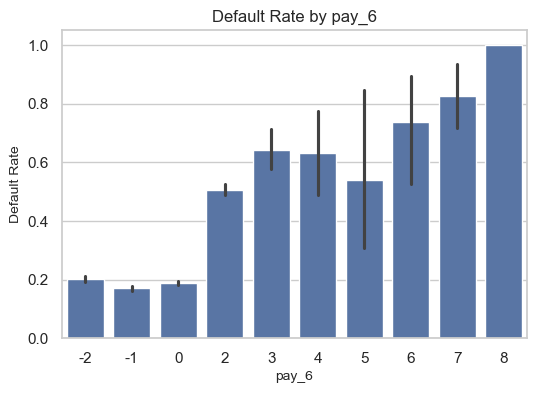

In [31]:
for col in pay_cols:
    plt.figure(figsize=(6,4))
    sns.barplot(
        x=col,
        y="default payment next month",
        data=df,
        estimator=lambda x: sum(x)/len(x)
    )
    plt.title(f"Default Rate by {col}")
    plt.ylabel("Default Rate")
    plt.show()

Observa-se um aumento monotônico da taxa de inadimplência conforme cresce o atraso no pagamento.

Esse padrão é mais acentuado nas variáveis mais recentes (especialmente `pay_0`), indicando que atrasos recentes possuem maior poder preditivo.

Clientes com atraso igual ou superior a 2 meses apresentam um salto significativo na probabilidade de inadimplência.

Esse comportamento reforça a hipótese de que o histórico recente de pagamento é um forte indicador de risco de crédito.

### 6.3.3 Credit Exposure

Análise do impacto do limite de crédito e valores de fatura no risco de inadimplência.

In [32]:
df.groupby("default payment next month")["limit_bal"].mean()

default payment next month
0    178099.726074
1    130109.656420
Name: limit_bal, dtype: float64

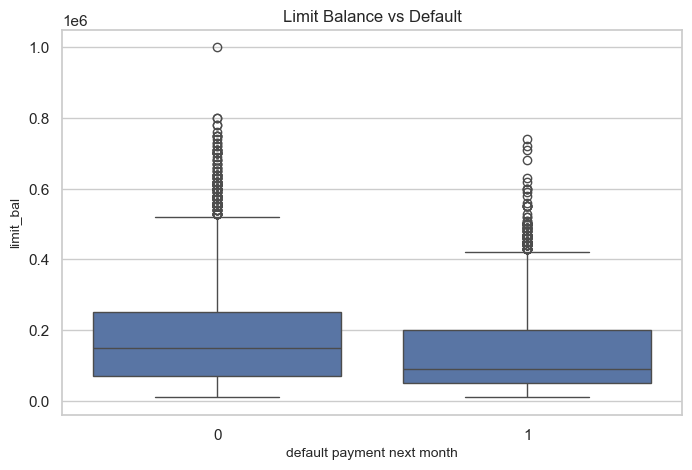

In [33]:
sns.boxplot(x="default payment next month", y="limit_bal", data=df)
plt.title("Limit Balance vs Default")
plt.show()

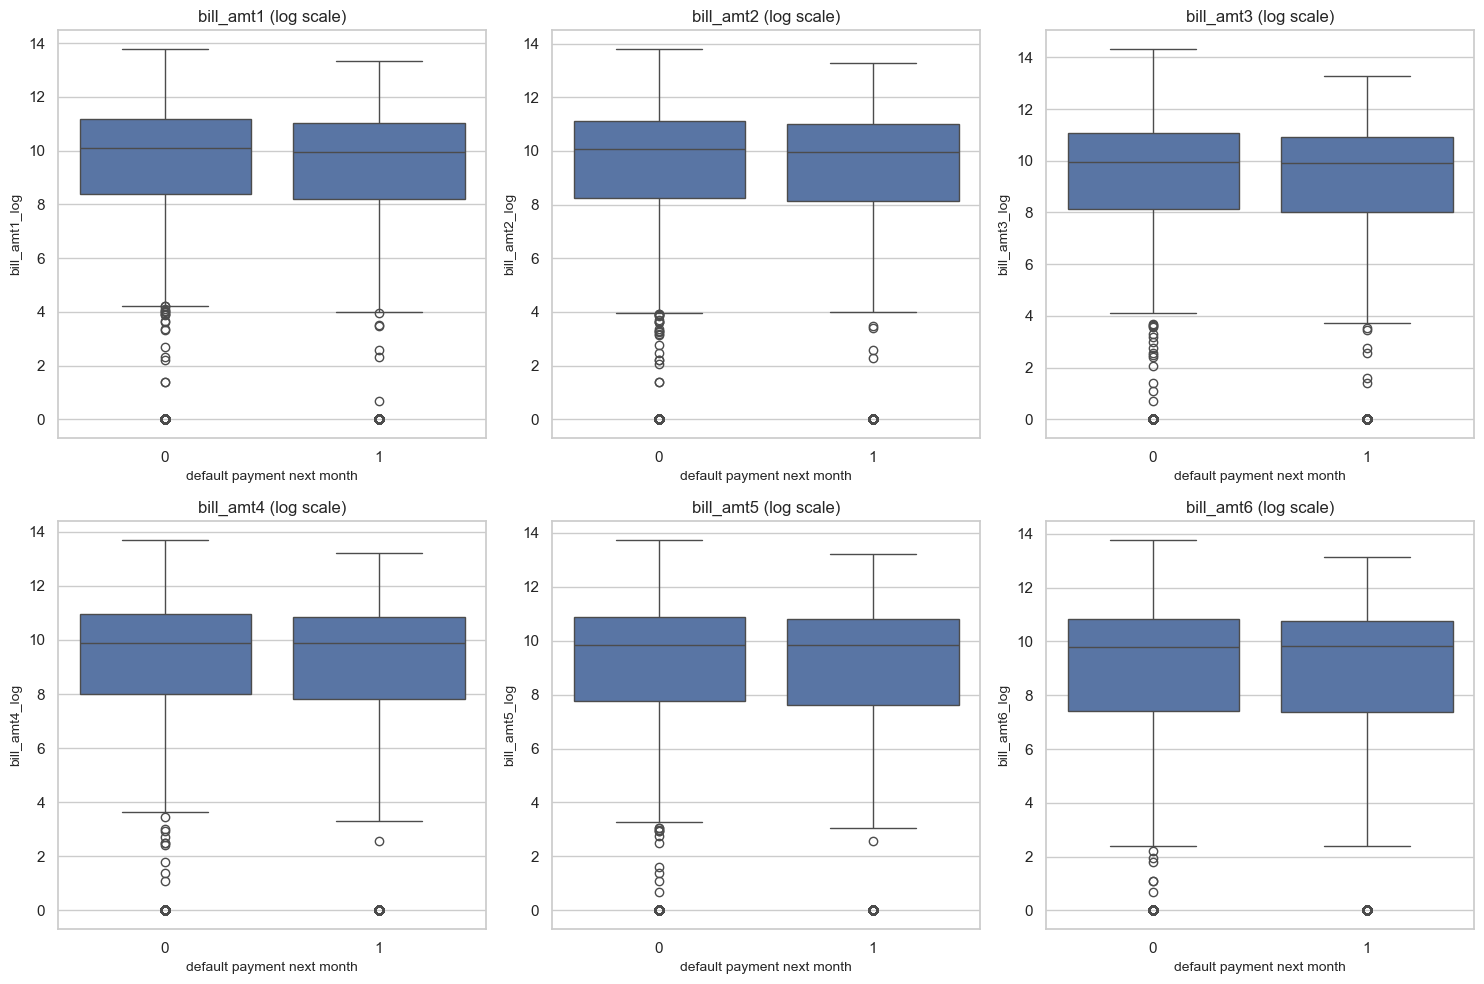

In [34]:
bill_cols = ["bill_amt1","bill_amt2","bill_amt3","bill_amt4","bill_amt5","bill_amt6"]

n_cols = 3
n_rows = math.ceil(len(bill_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(bill_cols):
    
    temp_col = f"{col}_log"
    df[temp_col] = np.log1p(df[col])
    
    sns.boxplot(
        data=df,
        x="default payment next month",
        y=temp_col,
        ax=axes[i]
    )
    
    axes[i].set_title(f"{col} (log scale)")

# Remove eixos vazios
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### 6.3.4 Payment Amount Behavior

Avaliação da relação entre valores pagos e inadimplência.

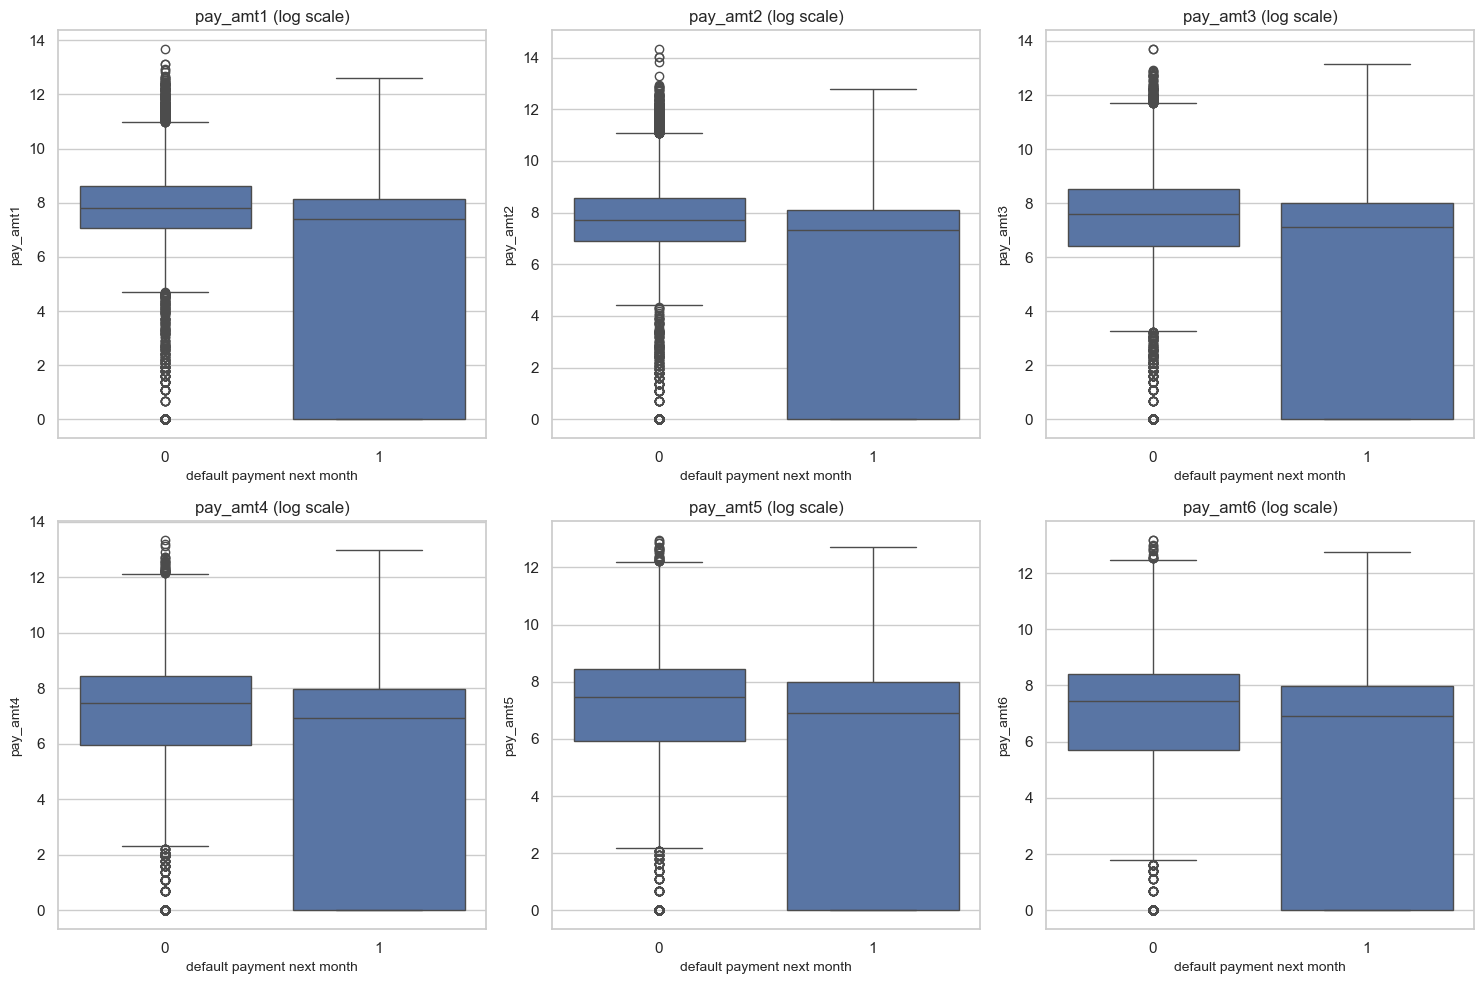

In [35]:
pay_amt_cols = ["pay_amt1","pay_amt2","pay_amt3","pay_amt4","pay_amt5","pay_amt6"]

n_cols = 3
n_rows = math.ceil(len(pay_amt_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(pay_amt_cols):
    
    sns.boxplot(
        data=df,
        x="default payment next month",
        y=np.log1p(df[col]),
        ax=axes[i]
    )
    
    axes[i].set_title(f"{col} (log scale)")

# Remove eixos extras
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Clientes inadimplentes tendem a apresentar valores de pagamento inferiores, reforçando a hipótese de pagamento parcial ou incapacidade de quitação da fatura.

Esse padrão está alinhado com o comportamento observado na análise univariada e sugere acúmulo progressivo de dívida.

### 6.3.5 Demographic Variables

Análise do impacto de variáveis demográficas no risco de inadimplência.

In [36]:
for col in ["sex", "education", "marriage"]:
    print(f"\n{col}")
    display(pd.crosstab(df[col], df["default payment next month"], normalize="index"))


sex


default payment next month,0,1
sex,,
1,0.758328,0.241672
2,0.792237,0.207763



education


default payment next month,0,1
education,,
1,0.807652,0.192348
2,0.762651,0.237349
3,0.748424,0.251576
4,0.929487,0.070513



marriage


default payment next month,0,1
marriage,,
1,0.765283,0.234717
2,0.790717,0.209283
3,0.763926,0.236074


Apesar de observarmos um caráter discriminatório forte analisando o default na variável education, em geral assumimos que essas variáveis demográficas não possuem grande poder discriminatório, uma vez que os grupos não parecem diferenciar-se de maneira significativa.

Embora a variável `education` apresente diferenças aparentes na taxa de inadimplência entre categorias, essas variações não indicam, de forma consistente, um forte poder discriminatório.

De maneira geral, as variáveis demográficas analisadas não evidenciam separações claras e robustas entre clientes inadimplentes e adimplentes, sugerindo baixo poder preditivo isolado.

Esse comportamento é esperado em problemas de risco de crédito, onde variáveis comportamentais — especialmente relacionadas ao histórico de pagamento — tendem a apresentar maior relevância.

Ainda assim, essas variáveis podem contribuir marginalmente para o modelo quando combinadas com outras features, capturando efeitos complementares ao comportamento financeiro do cliente.

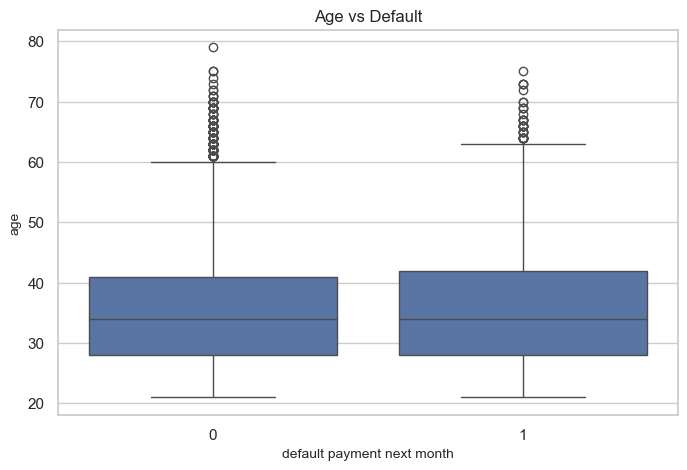

In [37]:
sns.boxplot(x="default payment next month", y="age", data=df)
plt.title("Age vs Default")
plt.show()

Variáveis demográficas apresentam menor poder discriminatório quando comparadas às variáveis comportamentais.

Apesar disso, pequenas diferenças podem ser observadas entre grupos, podendo contribuir marginalmente para o modelo.

### Correlação entre variáveis explicativas e target

In [38]:
df.corr(numeric_only=True)["default payment next month"].sort_values(ascending=False)

default payment next month    1.000000
pay_0                         0.324794
pay_2                         0.263551
pay_3                         0.235253
pay_4                         0.216614
pay_5                         0.204149
pay_6                         0.186866
education                     0.033842
age                           0.013890
bill_amt6                    -0.005372
bill_amt5                    -0.006760
bill_amt6_log                -0.008821
bill_amt4                    -0.010156
bill_amt3                    -0.014076
bill_amt2                    -0.014193
bill_amt3_log                -0.015498
bill_amt5_log                -0.017057
bill_amt4_log                -0.017767
bill_amt2_log                -0.018796
bill_amt1                    -0.019644
marriage                     -0.027575
bill_amt1_log                -0.032167
sex                          -0.039961
pay_amt6                     -0.053183
pay_amt5                     -0.055124
pay_amt3                 

### Complementary Insight

A análise de correlação com a variável alvo indica que variáveis relacionadas ao histórico de pagamento (`pay_*`) apresentam maior associação linear com a inadimplência.

Por outro lado, variáveis financeiras como valores de fatura e pagamento apresentam baixa correlação linear com o target, apesar de evidenciarem padrões relevantes na análise bivariada.

Isso reforça a limitação da correlação como métrica isolada e a importância de análises complementares para capturar relações não lineares.

## 6.3.6 Principais Achados

- Variáveis de histórico de pagamento (pay_*) apresentam o maior poder preditivo.
- Atrasos recentes são fortemente associados à inadimplência futura.
- Clientes inadimplentes apresentam, em média, menor limite de crédito.
- Há evidência de comportamento de pagamento parcial entre inadimplentes.
- Variáveis demográficas possuem menor relevância preditiva.

# **7. Feature Engineering**

### Objective

Criar novas variáveis que capturem melhor o comportamento de risco de crédito, aumentando o poder preditivo do modelo.

As features serão baseadas em:

- Histórico de pagamento
- Comportamento financeiro
- Relações entre fatura e pagamento

### 7.1 Payment Behavior Features

Dentro do meu feature engineering, começarei criando 4 variáveis associadas aos pagamentos.
- Uma para capturar o máximo de atraso recente entre as parcelas de pagamento;
- Uma para capturar a média de de atraso associada a cada cliente;
- Uma para o número de meses em atraso;
- E por último, uma para flaggar operações em atraso severo, pois conforme visto durante a análise bivariada, atraso superior a 2 meses costuma ser um fator preponderante para a existência do evento default.

### Máximo de atraso recente entre as parcelas de pagamento

In [39]:
pay_cols = ["pay_0","pay_2","pay_3","pay_4","pay_5","pay_6"]

df["max_delay"] = df[pay_cols].max(axis=1)

### Média de atraso

In [40]:
df["avg_delay"] = df[pay_cols].mean(axis=1)

### Número de meses em atraso

In [41]:
df["num_delays"] = (df[pay_cols] > 0).sum(axis=1)

### Flag de atraso severo

In [42]:
df["severe_delay"] = (df["max_delay"] >= 2).astype(int)

In [43]:
df.head(5)

,limit_bal,sex,education,marriage,age,pay_0,pay_2,pay_3,pay_4,pay_5,...,bill_amt1_log,bill_amt2_log,bill_amt3_log,bill_amt4_log,bill_amt5_log,bill_amt6_log,max_delay,avg_delay,num_delays,severe_delay
0,20000,2,2,1,24,2,2,-1,-1,-2,...,8.272315,8.040125,6.536692,0.000000,0.000000,0.000000,2,-0.333333,2,1
1,120000,2,2,2,26,-1,2,0,0,0,...,7.894691,7.453562,7.894691,8.093462,8.147867,8.090096,2,0.500000,2,1
2,90000,2,2,2,34,0,0,0,0,0,...,10.283293,9.548811,9.514880,9.570250,9.612400,9.651816,0,0.000000,0,0
3,50000,2,2,1,37,0,0,0,0,0,...,10.757711,10.783819,10.805517,10.251147,10.273671,10.293771,0,0.000000,0,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,9.061608,8.643121,10.486708,9.949464,9.859901,9.859118,0,-0.333333,0,0


### 7.2 Financial Behavior Features

Utilizando as variáveis de pagamento e fatura, buscarei trazer uma variável de razão pagamento/fatura que traz uma relação muito forte entre o evento default.

In [44]:
bill_cols = ["bill_amt1","bill_amt2","bill_amt3","bill_amt4","bill_amt5","bill_amt6"]

df["avg_bill"] = df[bill_cols].mean(axis=1)

In [45]:
pay_amt_cols = ["pay_amt1","pay_amt2","pay_amt3","pay_amt4","pay_amt5","pay_amt6"]

df["avg_payment"] = df[pay_amt_cols].mean(axis=1)

In [46]:
df["payment_ratio"] = df["avg_payment"] / (df["avg_bill"] + 1)

A interpretação aqui é simples. Ao dividir a média de pagamento pela média da fatura, dizemos o seguinte:
- Alto ratio -> cliente saudável
- Baixo ratio -> risco alto

### 7.3 Credit Utilization

Por último também buscarei criar uma razão de crédito utilizado, dividindo a média da utilização de crédito pelo limite de crédito disponível para cada associado.
Esta variável trará a razão do crédito utilizado, sendo:
- 1 = todo limite utilizado;
- 0 = nenhum limite utilizado.
Entretanto, o que importa aqui é o entendimento de que quanto mais próximo do limite, maior o risco de default.

De maneira a evitar problemas numéricos

### Data Integrity Validation

Apesar de já criar mecanismos para evitar a criação de zeros e infinitos, irei realizar uma verificação de integridade dos dados apenas para garantir a ausência de valores inválidos no dataset.

Desta forma, buscarei:

- Detectar valores infinitos (`inf` ou `-inf`), que podem surgir a partir de operações matemáticas como divisão por zero
- Identificar valores ausentes (`NaN`), que podem comprometer o treinamento de modelos

In [47]:
assert np.isinf(df).sum().sum() == 0, "Existem valores infinitos no dataset"
assert df.isnull().sum().sum() == 0, "Existem valores nulos no dataset"

AssertionError: Existem valores infinitos no dataset

Mesmo aplicando as boas práticas, alguma situação seguiu produzindo valores infinitos, desta forma irei tentar investigar quais colunas possuem valores infinitos.

In [48]:
np.isinf(df).sum().sort_values(ascending=False)

bill_amt6_log                 25
bill_amt4_log                 25
bill_amt3_log                 24
bill_amt5_log                 24
bill_amt2_log                 18
bill_amt1_log                 16
age                            0
education                      0
sex                            0
limit_bal                      0
marriage                       0
pay_0                          0
pay_2                          0
bill_amt3                      0
bill_amt4                      0
pay_3                          0
pay_4                          0
pay_5                          0
pay_6                          0
bill_amt1                      0
bill_amt2                      0
pay_amt4                       0
pay_amt3                       0
pay_amt2                       0
pay_amt1                       0
bill_amt6                      0
bill_amt5                      0
pay_amt5                       0
default payment next month     0
pay_amt6                       0
max_delay 

Conforme observado acima, as colunas com valores infinitos são decorrentes da transformação logaritmica que apliquei para visualização de gráficos.
Como estas variáveis foram criadas exclusivamente para minha etapa de EDA e estas não agregam valor direto, além de estarem corrompidas matematicamente, vou optar aqui por remover essas colunas apenas.

In [49]:
cols_to_drop = [col for col in df.columns if "_log" in col]
df.drop(columns=cols_to_drop, inplace=True)

Agora seguirei novamente para a verificação de NaN e inf.

In [50]:
assert np.isinf(df).sum().sum() == 0, "Existem valores infinitos no dataset"
assert df.isnull().sum().sum() == 0, "Existem valores nulos no dataset"

AssertionError: Existem valores nulos no dataset

Agora valores nulos estão aparecendo. Vou fazer, novamente, um mapeamento para entender onde estão tais casos.

In [51]:
df.isnull().sum().sort_values(ascending=False)

payment_ratio                 2
sex                           0
limit_bal                     0
marriage                      0
age                           0
pay_0                         0
education                     0
pay_3                         0
pay_4                         0
pay_5                         0
pay_6                         0
bill_amt1                     0
bill_amt2                     0
bill_amt3                     0
pay_2                         0
bill_amt4                     0
bill_amt5                     0
pay_amt1                      0
bill_amt6                     0
pay_amt3                      0
pay_amt4                      0
pay_amt5                      0
pay_amt2                      0
pay_amt6                      0
default payment next month    0
avg_delay                     0
max_delay                     0
num_delays                    0
severe_delay                  0
avg_bill                      0
avg_payment                   0
dtype: i

In [52]:
df.isnull().sum()[df.isnull().sum() > 0]

payment_ratio    2
dtype: int64

In [53]:
df[df["payment_ratio"].isnull()]

,limit_bal,sex,education,marriage,age,pay_0,pay_2,pay_3,pay_4,pay_5,...,pay_amt5,pay_amt6,default payment next month,max_delay,avg_delay,num_delays,severe_delay,avg_bill,avg_payment,payment_ratio
13650,260000,1,2,1,53,-2,-2,-2,-2,-2,...,0,0,0,-2,-2.0,0,0,-1.0,0.0,NaN
28804,360000,2,1,1,36,1,-2,-2,-2,-2,...,0,0,0,1,-1.5,1,0,-1.0,0.0,NaN


Minha hipótese aqui é que, ao criar minha variável 'payment_ratio' somando + 1 ao avg_bill, estes casos de avg_bill = -1 acabou por produzir zeros no denominador da fração. Pegando esses casos em específico, em que o numerador da fração (avg_payment) é zero também, acabou por se produzir uma divisão 0/0, ou seja, uma indeterminação matemática.
Para contornar estes casos, criarei um tratamento nesta variável criada, associando uma condicional a ela, de maneira a contornar esses casos atípicos.

In [54]:
df["payment_ratio"] = np.where(
    (df["avg_bill"] + 1) == 0,
    0,
    df["avg_payment"] / (df["avg_bill"] + 1)
)

In [55]:
assert np.isinf(df).sum().sum() == 0, "Existem valores infinitos no dataset"
assert df.isnull().sum().sum() == 0, "Existem valores nulos no dataset"

Pronto! Verificação e tratamento de casos inf e NaN finalizada.

### Feature Engineering Insights

As novas variáveis criadas capturam aspectos mais complexos do comportamento financeiro dos clientes, como intensidade de atraso, consistência de pagamento e nível de utilização de crédito.

Essas features permitem representar melhor o risco de inadimplência do que as variáveis originais isoladas, especialmente ao consolidar informações temporais e comportamentais.

### 7.4 Feature Selection

Após a etapa de EDA e criação de variáveis, o dataset contém tanto variáveis originais quanto derivadas.

Nesta etapa, buscamos:

- Remover variáveis irrelevantes ou redundantes
- Evitar multicolinearidade desnecessária
- Manter apenas variáveis com potencial preditivo

Observação:
Não será realizada uma seleção agressiva neste momento, pois modelos como regressão logística e árvores podem se beneficiar de diferentes representações dos dados.

Neste momento, com o modelo ainda não treinado, não possuo condições de avaliar a relevância mais aprofundada das variáveis, então um feature selection mais forte virá apenas após o primeiro modelo baseline.
Neste momento, conforme mencionado acima, a ideia é realizar uma limpeza leve - e não uma seleção de variáveis agressiva.
Dentro desta seleção leve, buscarei remover (se houver) variáveis inúteis por definição como:
- IDs;
- Colunas constantes;
- Colunas duplicadas.

Para tanto, iniciarei relembrando as colunas que tenho agora dentro do meu dataframe e observar se alguma está duplicada ou se existe alguma coluna de ID.

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 31 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   limit_bal                   30000 non-null  int64  
 1   sex                         30000 non-null  int64  
 2   education                   30000 non-null  int64  
 3   marriage                    30000 non-null  int64  
 4   age                         30000 non-null  int64  
 5   pay_0                       30000 non-null  int64  
 6   pay_2                       30000 non-null  int64  
 7   pay_3                       30000 non-null  int64  
 8   pay_4                       30000 non-null  int64  
 9   pay_5                       30000 non-null  int64  
 10  pay_6                       30000 non-null  int64  
 11  bill_amt1                   30000 non-null  int64  
 12  bill_amt2                   30000 non-null  int64  
 13  bill_amt3                   300

Aparentemente, nenhuma coluna possui informação duplicada e também não temos uma coluna de ID presente.
Agora passarei para a verificação de colunas constantes.

In [57]:
# Colunas com apenas um valor
df.nunique()[df.nunique() == 1]

Series([], dtype: int64)

Conforme saída do comando, nenhuma das colunas presentes no dataframe possui informação constante. Portanto, neste primeiro feature selection, não irei remover nenhuma coluna.

In [58]:
# Remoção de colunas auxiliares ou não utilizadas (se houver)

# Exemplo (ajuste conforme seu dataset)
cols_to_drop = [] # Conjunto dentro do cols_to_drop zerado pois não encontrei nenhuma variável a ser removida.

df_model = df.drop(columns=cols_to_drop)

Obs: apesar de possuir 'avg_bill' e todas 'bill_amt' presentes ainda no dataset, vou optar por não removê-las ainda neste momento, pois a informação, apesar de redundante, ainda pode ser útil. Desta forma, estrategicamente, optarei por mantê-las.

### 7.5 Definição de Variáveis Independentes e Target

Separamos o dataset em:

- X → Variáveis explicativas
- y → Variável alvo (default)

Essa separação é essencial para o treinamento supervisionado dos modelos.

In [59]:
X = df_model.drop("default payment next month", axis=1)
y = df_model["default payment next month"]

### 7.6 Identificação de Variáveis Categóricas

Algumas variáveis representam categorias, embora estejam codificadas numericamente:

- sex
- education
- marriage

Essas variáveis não possuem relação ordinal direta e devem ser tratadas como categóricas.

In [60]:
categorical_features = ["sex", "education", "marriage"]

### 7.7 Encoding de Variáveis Categóricas

Será utilizado One-Hot Encoding para transformar variáveis categóricas em formato numérico.

Motivação:

- Evita interpretação ordinal incorreta
- Compatível com modelos lineares
- Preserva independência entre categorias

A opção `drop_first=True` é utilizada para evitar multicolinearidade (dummy variable trap).

In [61]:
X = pd.get_dummies(X, columns=categorical_features, drop_first=True)

In [62]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 33 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   limit_bal      30000 non-null  int64  
 1   age            30000 non-null  int64  
 2   pay_0          30000 non-null  int64  
 3   pay_2          30000 non-null  int64  
 4   pay_3          30000 non-null  int64  
 5   pay_4          30000 non-null  int64  
 6   pay_5          30000 non-null  int64  
 7   pay_6          30000 non-null  int64  
 8   bill_amt1      30000 non-null  int64  
 9   bill_amt2      30000 non-null  int64  
 10  bill_amt3      30000 non-null  int64  
 11  bill_amt4      30000 non-null  int64  
 12  bill_amt5      30000 non-null  int64  
 13  bill_amt6      30000 non-null  int64  
 14  pay_amt1       30000 non-null  int64  
 15  pay_amt2       30000 non-null  int64  
 16  pay_amt3       30000 non-null  int64  
 17  pay_amt4       30000 non-null  int64  
 18  pay_am

### 7.8 Divisão em Treino e Teste

Conforme definido no Experimental Design:

- Holdout: 70% treino / 30% teste
- Estratificação pela variável alvo

A estratificação garante que a proporção de inadimplentes seja mantida em ambos os conjuntos.

In [63]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

Feita nossa estratificação, espera-se que 30% da base (9 mil registros) esteja alocada em test e o restante (70%, 21 mil informações) alocada em treino.

In [64]:
X_train.shape

(21000, 33)

In [65]:
X_test.shape

(9000, 33)

Conforme visto acima, a estratificação gerou o resultado esperado.

### 7.9 Feature Scaling

As variáveis numéricas apresentam grande variação de escala (ex: limite de crédito vs pagamentos).

Será utilizado StandardScaler para:

- Padronizar média = 0
- Padronizar desvio padrão = 1

Isso é essencial para modelos como regressão logística e KNN.

In [66]:
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Todas numéricas
numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns

# Binárias (0/1)
binary_cols = [col for col in numeric_cols if X_train[col].nunique() == 2]

# (Opcional) remover pay_* do scaling
pay_cols = ["pay_0","pay_2","pay_3","pay_4","pay_5","pay_6"]

# Variáveis contínuas finais
continuous_cols = [
    col for col in numeric_cols
    if col not in binary_cols and col not in pay_cols
]

# Aplicar scaling
X_train_scaled[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test_scaled[continuous_cols] = scaler.transform(X_test[continuous_cols])

In [67]:
print("Variáveis escaladas:")
print(continuous_cols)

print("\nVariáveis NÃO escaladas:")
print([col for col in X_train.columns if col not in continuous_cols])

Variáveis escaladas:
['limit_bal', 'age', 'bill_amt1', 'bill_amt2', 'bill_amt3', 'bill_amt4', 'bill_amt5', 'bill_amt6', 'pay_amt1', 'pay_amt2', 'pay_amt3', 'pay_amt4', 'pay_amt5', 'pay_amt6', 'max_delay', 'avg_delay', 'num_delays', 'avg_bill', 'avg_payment', 'payment_ratio']

Variáveis NÃO escaladas:
['pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6', 'severe_delay', 'sex_2', 'education_2', 'education_3', 'education_4', 'marriage_2', 'marriage_3']


### 7.10 Validação Final dos Dados

Antes da modelagem, garantimos que o dataset final:

- Não possui valores nulos
- Não possui valores infinitos
- Está completamente numérico

Isso evita falhas durante o treinamento dos modelos.

In [68]:
assert np.isinf(X_train_scaled).sum().sum() == 0
assert np.isinf(X_test_scaled).sum().sum() == 0

assert X_train_scaled.isnull().sum().sum() == 0
assert X_test_scaled.isnull().sum().sum() == 0

### Key Takeaways

- Variáveis categóricas foram corretamente codificadas
- Escalas foram padronizadas para evitar viés em modelos
- A divisão estratificada garante representatividade da classe alvo
- O dataset final está limpo, consistente e pronto para modelagem

Essa etapa garante que o desempenho dos modelos reflita padrões reais dos dados, e não problemas de preparação.

# **8. Modeling**

## 8.1 Baseline Model
Aqui estamos criando uma referência mínima para nosso modelo. Conforme elencado no início do projeto, nosso modelo necessariamente deverá superar uma acurácia 78%, que seria um modelo prevendo todos casos como "não default".

In [69]:
y_train.mean()

np.float64(0.2211904761904762)

In [70]:
# prever sempre "não default"
baseline_pred = [0] * len(y_test)

In [71]:
print(classification_report(y_test, baseline_pred))

              precision    recall  f1-score   support

           0       0.78      1.00      0.88      7009
           1       0.00      0.00      0.00      1991

    accuracy                           0.78      9000
   macro avg       0.39      0.50      0.44      9000
weighted avg       0.61      0.78      0.68      9000



## 8.2 Logistic Regression
Como citado no início do projeto, vamos iniciar utilizando um modelo de regressão logística por entender ele como ideal para este tipo de problema, pois:
- É facilmente interpretável;
- É bastante utilizado em problemas de crédito;
- É um modelo que contém um bom nível de simplicidade.

Vamos iniciar treinando o modelo

In [72]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [73]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:,1]

## 8.3 Avaliação do modelo
Vamos fazer a avaliação inicial do modelo, partindo dos critérios estabelecidos anteriormente e avaliando os resultados obtidos.

In [74]:
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.84      0.94      0.88      7009
           1       0.63      0.35      0.45      1991

    accuracy                           0.81      9000
   macro avg       0.73      0.64      0.67      9000
weighted avg       0.79      0.81      0.79      9000

[[6597  412]
 [1303  688]]
ROC-AUC: 0.7559523992937544


Para a classe 0 -> não default, obtivemos: 
- Precision: 0.84. Ou seja, quando o modelo diz "não vai dar default", ele tem acertado 84% das vezes.
- Recall: 0.94. Desta forma, tem conseguido identificar 94% dos bons clientes.
- Aqui podemos considerar este resultado bastante bom.

Para a classe 1 -> default:
- Precision: 0.63. Portanto, dos que ele disse que vão dar default, 63% realmente dão.
- Recall: 0.35. Nosso modelo tem conseguido pegar apenas 35% dos inadimplentes reais.
- Aqui temos um forte sinal de alerta, uma vez que o modelo tem deixado passar muitos inadimplentes.

Matriz de Confusão:
- 1304 inadimplentes foram classificados como bons clientes. Este é o pior erro possível (o que chamamos de falso negativo), pois para problemas de crédito, significa que estamos aprovando crédito para quem não vai pagar, gerando perda financeira.

Accuracy: 0.81. 
- Visualizando sem muito aprofundamento parece um bom resultado, entretanto devemos considerar aqui os falsos negativos que constituem um forte problema no modelo, além de termos um dataset desbalanceado entre os eventos.

ROC-AUC: 0.7558. 
- Geralmente trabalhamos com um limiar de 0.8 pra mais para considerarmos um modelo como sendo muito bom. Entretanto, este valor de 0.7558 podemos considerar um resultado típico de um bom modelo.

### Análise do Modelo

O modelo alcançou uma acurácia geral de 81% e uma pontuação ROC-AUC de aproximadamente 0,76, indicando uma capacidade razoável de discriminar entre clientes inadimplentes e não inadimplentes.

No entanto, uma análise mais aprofundada revela uma limitação importante: a taxa de recall para a classe de inadimplentes é de apenas 35%. Isso significa que uma parcela significativa de clientes de alto risco não está sendo identificada corretamente.

Do ponto de vista comercial, isso é crítico, pois falsos negativos (clientes inadimplentes classificados como de baixo risco) representam uma potencial perda financeira.

Isso sugere que o limiar de classificação de inadimplência (0,5) pode não ser o ideal e deve ser ajustado para melhorar a detecção de clientes de alto risco.

## 8.4 Ajuste de Treshold
Conforme visto acima, algumas considerações nos indicam um treshold mal ajustado, além disto um limiar de 0.5 não possui grande tradição em problemas de crédito. Vamos, portanto realizar um ajuste deste limiar visando aumentar recall da classe 1 e reduzir falsos negativos.

In [75]:
threshold = 0.3
y_pred_adj = (y_prob >= threshold).astype(int)

In [76]:
print(classification_report(y_test, y_pred_adj))
print(confusion_matrix(y_test, y_pred_adj))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.87      0.85      0.86      7009
           1       0.50      0.54      0.52      1991

    accuracy                           0.78      9000
   macro avg       0.68      0.69      0.69      9000
weighted avg       0.78      0.78      0.78      9000

[[5926 1083]
 [ 924 1067]]
ROC-AUC: 0.7559523992937544


In [77]:
threshold = 0.4
y_pred_adj_2 = (y_prob >= threshold).astype(int)

In [78]:
print(classification_report(y_test, y_pred_adj_2))
print(confusion_matrix(y_test, y_pred_adj_2))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.85      0.91      0.88      7009
           1       0.58      0.44      0.50      1991

    accuracy                           0.80      9000
   macro avg       0.71      0.68      0.69      9000
weighted avg       0.79      0.80      0.80      9000

[[6360  649]
 [1109  882]]
ROC-AUC: 0.7559523992937544


In [79]:
threshold = 0.2
y_pred_adj_3 = (y_prob >= threshold).astype(int)

In [80]:
print(classification_report(y_test, y_pred_adj_3))
print(confusion_matrix(y_test, y_pred_adj_3))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.88      0.77      0.82      7009
           1       0.43      0.62      0.51      1991

    accuracy                           0.74      9000
   macro avg       0.66      0.70      0.66      9000
weighted avg       0.78      0.74      0.75      9000

[[5384 1625]
 [ 752 1239]]
ROC-AUC: 0.7559523992937544


In [81]:
threshold = 0.1
y_pred_adj_4 = (y_prob >= threshold).astype(int)

In [82]:
print(classification_report(y_test, y_pred_adj_4))
print(confusion_matrix(y_test, y_pred_adj_4))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.93      0.25      0.39      7009
           1       0.26      0.93      0.41      1991

    accuracy                           0.40      9000
   macro avg       0.60      0.59      0.40      9000
weighted avg       0.78      0.40      0.40      9000

[[1745 5264]
 [ 132 1859]]
ROC-AUC: 0.7559523992937544


### Análise de Otimização de Threshold

Diferentes limiares de classificação foram avaliados para equilibrar a relação entre precisão e recall para a classe de inadimplência.

Limiares mais baixos melhoram significativamente o recall, permitindo que o modelo identifique uma proporção maior de clientes de alto risco. No entanto, isso ocorre à custa de menor precisão e aumento de falsos positivos.

Entre os valores testados, um limiar de 0,3 proporcionou o melhor equilíbrio entre a detecção de clientes inadimplentes e a manutenção de uma precisão razoável.

Do ponto de vista comercial, o limiar ideal depende da tolerância ao risco da instituição. Limiares mais baixos são adequados para estratégias conservadoras focadas na minimização de perdas financeiras, enquanto limiares mais altos favorecem a aquisição de clientes e as taxas de aprovação.

In [83]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

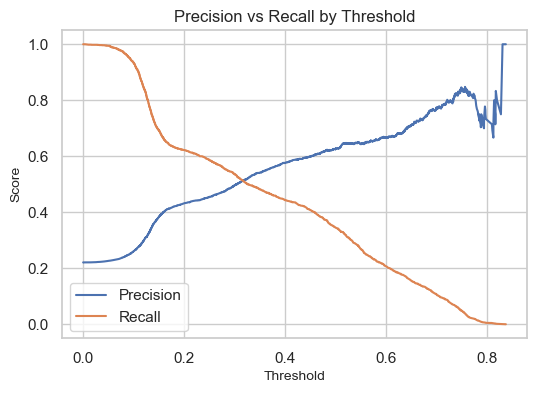

In [84]:
plt.figure(figsize=(6,4))
plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision vs Recall by Threshold")
plt.legend()
plt.show()

In [85]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

In [86]:
# garantir alinhamento
min_len = min(len(thresholds), len(precision), len(recall))

precision_adj = precision[:min_len]
recall_adj = recall[:min_len]
thresholds_adj = thresholds[:min_len]

# calcular F1
f1_scores = 2 * (precision_adj * recall_adj) / (precision_adj + recall_adj)
f1_scores = np.nan_to_num(f1_scores)

# melhor índice
best_idx = np.argmax(f1_scores)

print("Melhor threshold:", thresholds_adj[best_idx])
print("F1-score:", f1_scores[best_idx])

Melhor threshold: 0.03111133540270166
F1-score: 0.4239348518824501


### Otimização do Threshold usando a Pontuação F1

O limiar ideal baseado na pontuação F1 foi de 0,031, resultando em uma pontuação F1 de 0,424.

Esse threshold muito baixo indica que o modelo tende a classificar uma grande parte dos clientes como inadimplentes para maximizar o recall.

Embora isso melhore o equilíbrio entre precisão e recall, pode não ser adequado do ponto de vista comercial, pois leva a um alto número de falsos positivos (rejeição de clientes confiáveis).

Portanto, embora útil como linha de base, a pontuação F1 por si só não é suficiente para a tomada de decisões neste contexto.

In [87]:
target_recall = 0.60

valid_idx = np.where(recall >= target_recall)[0]

best_idx = valid_idx[0]  # menor threshold que atende a regra

best_threshold = thresholds[best_idx]

print("Threshold escolhido:", best_threshold)
print("Recall:", recall[best_idx])
print("Precision:", precision[best_idx])

Threshold escolhido: inf
Recall: 1.0
Precision: 0.2212222222222222


### Seleção de Threshold com Base na Restrição de Recall

Um threshold foi selecionado para satisfazer a restrição de recall ≥ 0,60. No entanto, o limiar resultante foi infinito, correspondendo a um recall de 1,0 e uma precisão de 0,22.

Isso ocorre porque a curva de precisão-recall inclui um ponto inicial onde todas as observações são classificadas como positivas, resultando em recall máximo, mas precisão extremamente baixa.

Do ponto de vista comercial, essa solução não é viável, pois levaria à rejeição de quase todos os clientes.

Isso destaca a importância de selecionar thresholds com cuidado, indo além de restrições ingênuas e considerando o equilíbrio entre recall e precisão.

In [88]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# alinhar corretamente
precision_adj = precision[:-1]
recall_adj = recall[:-1]
thresholds_adj = thresholds

# garantir mesmo tamanho
min_len = min(len(precision_adj), len(recall_adj), len(thresholds_adj))

precision_adj = precision_adj[:min_len]
recall_adj = recall_adj[:min_len]
thresholds_adj = thresholds_adj[:min_len]

# aplicar regra de recall
target_recall = 0.60

valid_idx = np.where(recall_adj >= target_recall)[0]

# segurança extra
if len(valid_idx) == 0:
    print("Nenhum threshold atende o recall desejado")
else:
    best_idx = valid_idx[-1]  # maior threshold possível
    
    print("Threshold escolhido:", thresholds_adj[best_idx])
    print("Recall:", recall_adj[best_idx])
    print("Precision:", precision_adj[best_idx])

Threshold escolhido: 0.23569767172323647
Recall: 0.6002009040683074
Precision: 0.4468960359012715


### Seleção de Threshold com Base na Restrição de Recall

Para garantir a identificação adequada de clientes de alto risco, foi estabelecido um limiar mínimo de recall de 60%.

Após o alinhamento adequado das matrizes de precisão, recall e limiar, o limiar ideal que satisfaz essa restrição foi encontrado como sendo 0,236.

Nesse limiar:
- Recall = 0,60 → o modelo identifica corretamente 60% dos clientes inadimplentes
- Precisão = 0,45 → aproximadamente 45% dos inadimplentes previstos são realmente de alto risco

Esse resultado representa um equilíbrio viável e operacional. Embora alguns clientes confiáveis ​​ainda possam ser classificados incorretamente como de alto risco (falsos positivos), o modelo captura efetivamente uma parcela significativa de potenciais inadimplentes.

Comparado a limiares mais agressivos (por exemplo, baseados em F1), essa abordagem fornece uma regra de decisão mais conservadora e alinhada aos negócios, reduzindo rejeições desnecessárias e mantendo o controle de risco.

In [89]:
cost_fn = 1000  # falso negativo (inadimplente aprovado)
cost_fp = 100   # falso positivo (bom cliente recusado)

In [90]:
costs = []

for t in thresholds:
    y_pred_temp = (y_prob >= t).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_temp).ravel()
    
    total_cost = fn * cost_fn + fp * cost_fp
    costs.append(total_cost)

best_idx = np.argmin(costs)
best_threshold = thresholds[best_idx]

print("Melhor threshold:", best_threshold)
print("Custo mínimo:", costs[best_idx])

Melhor threshold: 0.10228113164728736
Custo mínimo: 656700


### Otimização de Threshold Baseada em Custo

Uma abordagem sensível a custos foi aplicada para determinar o threshold de classificação ideal.

O custo de um falso negativo (aprovar um cliente inadimplente) foi definido como 1000, enquanto o custo de um falso positivo (rejeitar um cliente confiável) foi definido como 100.

O limiar ideal identificado foi 0,102, resultando no custo total mínimo de 656.700.

Esse threshold reflete uma estratégia mais conservadora, priorizando a redução de erros de alto impacto (falsos negativos), mesmo que isso signifique aumentar os falsos positivos.

Do ponto de vista comercial, essa abordagem é a mais adequada, pois alinha as decisões do modelo com a gestão de riscos financeiros.

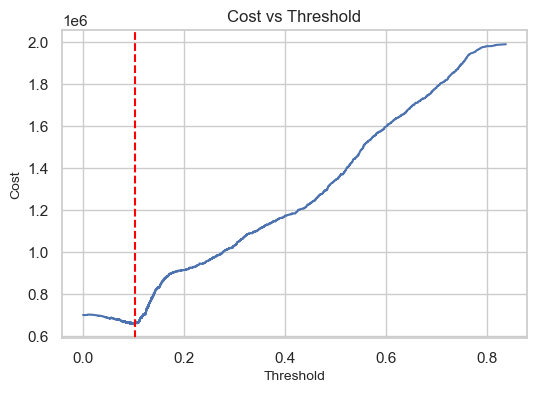

In [91]:
plt.figure(figsize=(6,4))
plt.plot(thresholds, costs)
plt.axvline(best_threshold, color='red', linestyle='--')

plt.title("Cost vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("Cost")
plt.show()

### Estratégia Final de Seleção de Threshold

Três abordagens diferentes foram avaliadas para a seleção do limiar:

- Otimização por F1-score, que resultou em um limiar muito baixo e uma estratégia de classificação excessivamente agressiva.
- Seleção baseada em recall, que, após o devido alinhamento, produziu um limiar equilibrado, garantindo os requisitos mínimos de recall.
- Otimização baseada em custo, que forneceu uma solução financeiramente ótima.

O limiar baseado em recall (0,236) garante que pelo menos 60% dos inadimplentes sejam identificados, oferecendo um equilíbrio controlado entre detecção de risco e aprovação do cliente.

Aqui, qualquer um dos modelos poderia ser utilizado tranquilamente, a depender da estratégia de negócio utilizada:

- Se o foco é crescimento + experiência do cliente → use recall-based
- Se o foco é redução de prejuízo → use cost-based

Aqui vamos considerar que o limiar baseado em custo permanece o mais alinhado aos objetivos de negócios, pois minimiza explicitamente as perdas financeiras.

# **9. Model Comparison**
Aqui nosso objetivo é testar novos modelos, compará-los e decidir se a regressão logística é realmente a melhor escolha dentro do nosso problema de negócio a ser resolvido.
Para tanto, iremos testar 2 novos modelos dentro desta seção:
- Random Forest
- Gradient Boosting (ou XGBoost)

### Considerações sobre o Feature Scaling

O escalonamento de atributos foi aplicado ao modelo de Regressão Logística para garantir a convergência adequada e a estimativa balanceada dos coeficientes, visto que esse modelo é sensível à magnitude dos atributos.

Entretanto, modelos baseados em árvores, como Random Forest e Gradient Boosting, não requerem escalonamento de atributos, pois se baseiam em limiares de decisão em vez de cálculos baseados em distância.

Portanto, esses modelos serão treinados usando o conjunto de dados original (sem escalonamento).

### Random Forest

In [92]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

y_prob_rf = rf.predict_proba(X_test)[:,1]

### Gradient Boosting

In [93]:
gb = GradientBoostingClassifier(random_state=42)

gb.fit(X_train, y_train)

y_prob_gb = gb.predict_proba(X_test)[:,1]

Aqui vamos manter o threshold de comparação fixo, conforme escolhido anteriormente.

In [94]:
threshold = 0.102  
def evaluate_model(y_test, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    f1 = 2 * (precision * recall) / (precision + recall)
    cost = fn * 1000 + fp * 100
    
    return precision, recall, f1, cost

In [95]:
y_prob_log = model.predict_proba(X_test_scaled)[:,1]
y_prob_rf = rf.predict_proba(X_test)[:,1]
y_prob_gb = gb.predict_proba(X_test)[:,1]

In [96]:
results = []

models = {
    "Logistic Regression": y_prob_log,
    "Random Forest": y_prob_rf,
    "Gradient Boosting": y_prob_gb
}

for name, y_prob in models.items():
    
    precision, recall, f1, cost = evaluate_model(y_test, y_prob, threshold)
    
    results.append([name, precision, recall, f1, cost])

In [97]:
results_df = pd.DataFrame(results, columns=[
    "Model", "Precision", "Recall", "F1-Score", "Cost"
])

results_df.sort_values("Cost")

,Model,Precision,Recall,F1-Score,Cost
2,Gradient Boosting,0.290427,0.897539,0.438851,640600
0,Logistic Regression,0.263683,0.929181,0.410792,657600
1,Random Forest,0.283145,0.869915,0.427232,697500


In [98]:
def evaluate_model(y_test, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    f1 = 2 * (precision * recall) / (precision + recall)
    cost = fn * 1000 + fp * 100
    
    return precision, recall, f1, cost, fp, fn

In [99]:
results = []

for name, y_prob in models.items():
    
    precision, recall, f1, cost, fp, fn = evaluate_model(y_test, y_prob, threshold)
    
    results.append([name, precision, recall, f1, cost, fp, fn])

In [100]:
results_df = pd.DataFrame(results, columns=[
    "Model", "Precision", "Recall", "F1", "Cost", "FP", "FN"
])

results_df.sort_values("Cost")

,Model,Precision,Recall,F1,Cost,FP,FN
2,Gradient Boosting,0.290427,0.897539,0.438851,640600,4366,204
0,Logistic Regression,0.263683,0.929181,0.410792,657600,5166,141
1,Random Forest,0.283145,0.869915,0.427232,697500,4385,259


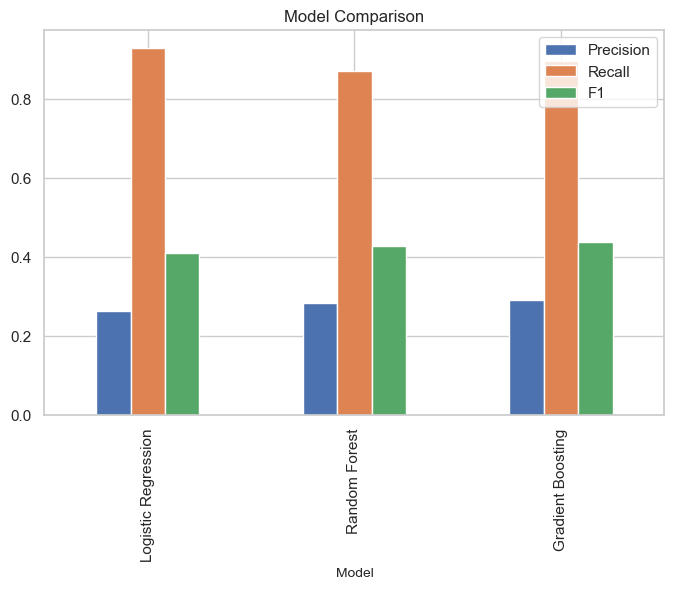

In [101]:
results_df.set_index("Model")[["Precision","Recall","F1"]].plot(kind="bar")
plt.title("Model Comparison")
plt.show()

## Comparação de Modelos

Diferentes modelos foram avaliados utilizando o mesmo limiar de decisão e função de custo para garantir uma comparação justa.

Os resultados mostram o desempenho de cada modelo em termos de precisão, recall, pontuação F1 e impacto financeiro.

Esta análise permite selecionar o modelo mais adequado com base nos objetivos de negócios, em vez de apenas no desempenho estatístico.

Com a nossa decisão de penalizar excessivamente os Falsos Negativos, temos modelos performando com alta recall, ou seja, estão detectando praticamente todos os inadimplentes, mas a custo de precisões mais baixas, o que acaba por penalizar clientes bons. Desta forma, podemos traduzir a nível de negócio a nossa decisão da seguinte maneira:
- Buscamos uma política de crédito mais restritiva, visando capturar quase todos os clientes inadimplentes e reduzindo o risco de exposição da instituição, mas a um custo de menores aprovações de crédito e eventual perda de receita em alguns momentos.

Cabe destacar que o modelo pode tranquilamente ser ajustado, alterando os pesos de FP E FN que definimos acima a partir do direcionamento de negócio que deseja ser dado.

In [102]:
print("Logistic:", roc_auc_score(y_test, y_prob_log))
print("RF:", roc_auc_score(y_test, y_prob_rf))
print("GB:", roc_auc_score(y_test, y_prob_gb))

Logistic: 0.7559523992937544
RF: 0.7552208293004066
GB: 0.7796847118926308


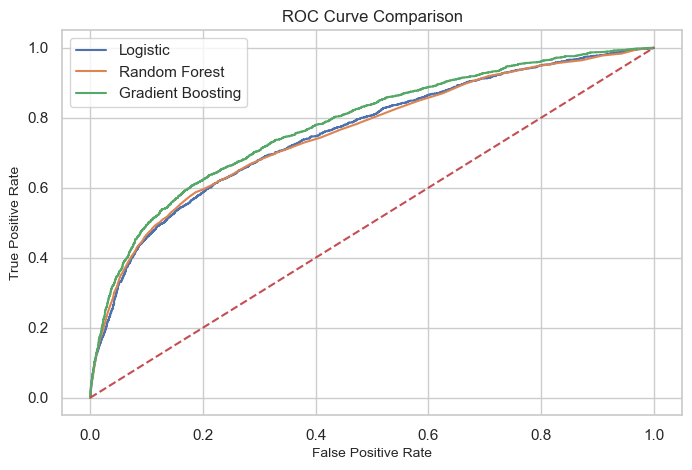

In [103]:
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)

plt.plot(fpr_log, tpr_log, label="Logistic")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot(fpr_gb, tpr_gb, label="Gradient Boosting")

plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

## Avaliação do Modelo vs. Limiar de Decisão

É importante distinguir entre avaliação do modelo e tomada de decisão.

A ROC-AUC foi utilizada como métrica principal para avaliar a capacidade do modelo de discriminar entre clientes inadimplentes e não inadimplentes, independentemente de qualquer limiar de classificação.

No entanto, decisões de negócios exigem um limiar específico para classificar os clientes. Portanto, a otimização do limiar foi realizada separadamente, com base em métricas orientadas a negócios, como recall e custo.

Essa separação garante que o modelo seja estatisticamente sólido e esteja alinhado com os requisitos de tomada de decisão do mundo real.

## Comparação da Capacidade Discriminatória dos Modelos (ROC-AUC)

A métrica principal definida no desenho experimental foi o ROC-AUC.

Diferentemente de métricas dependentes de threshold, como precisão e recall, o ROC-AUC mede a capacidade geral do modelo em distinguir clientes inadimplentes de clientes adimplentes, considerando todos os thresholds possíveis.

*Resultados*

Modelo	ROC-AUC

Regressão Logística	0.756

Random Forest	0.755

Gradient Boosting	0.780

*Interpretação*

Os resultados indicam que o modelo de Gradient Boosting apresentou a melhor capacidade discriminatória entre os modelos avaliados.

Isso significa que, ao comparar aleatoriamente um cliente inadimplente com um cliente adimplente, o Gradient Boosting possui maior probabilidade de atribuir uma pontuação de risco mais elevada ao cliente inadimplente.

Por outro lado:

O Random Forest apresentou desempenho praticamente equivalente à Regressão Logística;

O ganho de complexidade introduzido pelo Random Forest não se traduziu em melhoria relevante de desempenho;

O Gradient Boosting foi o único modelo que apresentou melhora consistente tanto na métrica estatística principal (ROC-AUC) quanto na métrica de negócio baseada em custo.

Esses resultados sugerem que o dataset possui relações não lineares que são capturadas de forma mais eficiente pelo Gradient Boosting do que por modelos lineares tradicionais.

# **10. Model Validation and Optimization**

## 10.1 Cross-Validation Evaluation
*Objetivo*

Até este momento, os modelos foram avaliados utilizando apenas uma divisão Holdout (70/30). Embora essa abordagem seja adequada para uma primeira avaliação, os resultados podem ser influenciados pela composição específica da amostra de treino e teste.

Conforme definido no Experimental Design, será utilizada validação cruzada estratificada com 5 folds para:

    Avaliar a estabilidade dos modelos;
    Reduzir a variância da estimativa de performance;
    Detectar possíveis sinais de overfitting;
    Obter uma medida mais robusta da capacidade de generalização.


A métrica principal utilizada continuará sendo o ROC-AUC.

In [104]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

models = {
    "Logistic Regression": model,
    "Random Forest": rf,
    "Gradient Boosting": gb
}

for name, model in models.items():

    scores = cross_val_score(
        model,
        X_train_scaled if name == "Logistic Regression" else X_train,
        y_train,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    print(f"\n{name}")
    print(f"Mean ROC-AUC: {scores.mean():.4f}")
    print(f"Std ROC-AUC: {scores.std():.4f}")


Logistic Regression
Mean ROC-AUC: 0.7642
Std ROC-AUC: 0.0094

Random Forest
Mean ROC-AUC: 0.7633
Std ROC-AUC: 0.0094

Gradient Boosting
Mean ROC-AUC: 0.7838
Std ROC-AUC: 0.0083


## Interpretação dos Resultados

Os resultados demonstram que o modelo de Gradient Boosting apresentou o melhor desempenho médio entre todos os algoritmos avaliados.

Além de possuir o maior ROC-AUC médio, o modelo também apresentou o menor desvio padrão entre os folds, indicando maior estabilidade e menor sensibilidade às variações das amostras de treinamento.

A diferença observada em relação à Regressão Logística e ao Random Forest é consistente tanto na avaliação Holdout quanto na Validação Cruzada, reforçando a evidência de que o ganho obtido não decorre de uma divisão específica dos dados.

## Conclusão

Com base nos resultados obtidos, o Gradient Boosting foi selecionado como modelo candidato para as etapas finais do projeto.

A escolha foi motivada por:

Maior capacidade discriminatória (ROC-AUC);
Melhor estabilidade entre os folds;
Melhor desempenho observado nas métricas de negócio avaliadas anteriormente.

Dessa forma, as próximas etapas serão concentradas na otimização e interpretação deste modelo.

## 10.2 Otimização de Hiperparâmetros

Após a seleção do modelo vencedor, será realizada uma etapa de otimização de hiperparâmetros com o objetivo de maximizar sua capacidade de generalização.

Embora os parâmetros padrão forneçam um ponto de partida adequado, a performance de algoritmos baseados em árvores pode variar significativamente conforme a configuração utilizada.

O processo de otimização busca identificar combinações capazes de produzir ganhos adicionais de desempenho sem comprometer a estabilidade do modelo.

In [107]:
param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [2, 3, 4, 5],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5]
}

search = RandomizedSearchCV(
    estimator=gb,
    param_distributions=param_grid,
    n_iter=50,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_gb = search.best_estimator_

print("Melhores parâmetros:")
print(search.best_params_)

print("\nMelhor ROC-AUC:")
print(search.best_score_)

Melhores parâmetros:
{'subsample': 0.7, 'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 5, 'learning_rate': 0.01}

Melhor ROC-AUC:
0.7855012523204372


## 10.3 Comparação Antes vs Depois do Tuning

In [108]:
print("ROC-AUC Original:", 0.7838)
print("ROC-AUC Tunado:", search.best_score_)

ROC-AUC Original: 0.7838
ROC-AUC Tunado: 0.7855012523204372


## Interpretação

Observa-se um ganho absoluto de aproximadamente 0.0017 pontos de ROC-AUC após o processo de otimização.

Embora a melhoria seja positiva, sua magnitude é relativamente pequena quando comparada ao desempenho já obtido pelo modelo original.

Esse resultado sugere que a configuração padrão do algoritmo já se encontrava próxima de uma região de bom desempenho para este conjunto de dados.

## Conclusão
O aumento absoluto de aproximadamente 0.0017 pontos sugere que o modelo original já se encontrava próximo de uma configuração eficiente para este conjunto de dados.

Sob a perspectiva prática, o ganho obtido pode não justificar o aumento de complexidade associado à manutenção e documentação de múltiplos hiperparâmetros ajustados.

Dessa forma, optou-se por manter o modelo original como versão final do projeto, priorizando simplicidade, reprodutibilidade e facilidade de interpretação sem perda material de desempenho.

# **11. Feature Importance**

*Objetivo*

Identificar quais variáveis tiveram maior contribuição para as previsões do modelo.

In [109]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": gb.feature_importances_
})

importance = (
    importance
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

importance.head(20)

,Feature,Importance
0,pay_0,0.528343
1,num_delays,0.135596
2,max_delay,0.054196
3,severe_delay,0.035088
4,avg_delay,0.033421
5,avg_payment,0.027817
6,payment_ratio,0.025371
7,limit_bal,0.024563
8,bill_amt1,0.023319
9,avg_bill,0.022708


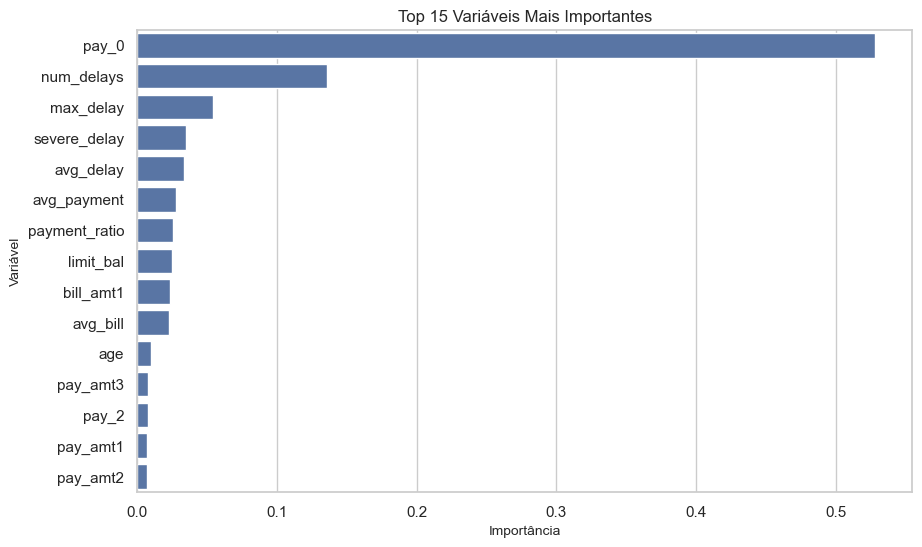

In [110]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Variáveis Mais Importantes")
plt.xlabel("Importância")
plt.ylabel("Variável")

plt.show()

## Interpretação dos Resultados

A análise de importância das variáveis revela que o histórico de pagamento é, de forma significativa, o principal determinante da inadimplência futura.

Observa-se que aproximadamente 70% da importância total do modelo está concentrada em variáveis relacionadas ao comportamento histórico de atraso.

Esse resultado é consistente com a literatura de risco de crédito, na qual o histórico de pagamento costuma representar o fator individual mais relevante para previsão de inadimplência.

*Papel do Histórico Recente*

A variável pay_0, que representa o status de pagamento mais recente do cliente, apresentou importância superior a 50%, tornando-se a principal variável explicativa do modelo.

Esse resultado sugere que o comportamento de pagamento imediatamente anterior ao período analisado contém forte sinal preditivo sobre a probabilidade de inadimplência futura.

Em termos de negócio, clientes que apresentam atraso recente possuem risco significativamente maior de entrar em *default* no mês seguinte.

*Validação das Features Criadas*

As variáveis derivadas construídas durante a etapa de Feature Engineering também apresentaram relevância significativa:

- num_delays: 13.6%
- max_delay: 5.4%
- severe_delay: 3.5%
- avg_delay: 3.3%
- payment_ratio: 2.5%

Esses resultados indicam que a agregação do histórico de pagamento foi capaz de capturar padrões adicionais não representados pelas variáveis originais.

Portanto, a etapa de engenharia de atributos contribuiu efetivamente para aumentar a capacidade preditiva do modelo.

*Papel das Variáveis Financeiras*

As variáveis relacionadas a faturas e pagamentos apresentaram importância intermediária:

- avg_payment: 2.8%
- bill_amt1: 2.3%
- avg_bill: 2.3%
- limit_bal: 2.5%

Isso sugere que informações sobre exposição financeira e capacidade de pagamento complementam o histórico de atraso, mas possuem menor poder explicativo isoladamente.

*Papel das Variáveis Demográficas*

As variáveis demográficas apresentaram baixa relevância no modelo.

Exemplos:

- age: 0.98%
- education_4: 0.57%

Esse resultado reforça os achados observados durante a análise exploratória, onde características demográficas apresentaram baixo poder discriminatório em comparação às variáveis comportamentais.

*Conclusão*

Os resultados indicam que a inadimplência futura é explicada predominantemente pelo comportamento histórico de pagamento do cliente.

O modelo aprendeu que atrasos recentes, recorrência de atrasos e severidade dos atrasos possuem muito mais capacidade preditiva do que características demográficas ou mesmo valores absolutos de fatura.

Esse comportamento está alinhado com práticas consolidadas de análise de risco de crédito e aumenta a confiabilidade dos resultados obtidos.

# **12. Final Model Evaluation**

In [111]:
y_prob_gb = gb.predict_proba(X_test)[:,1]

Aqui resgatamos o threshold cost-based.

In [112]:
threshold = 0.10228113164728736

In [113]:
y_pred_final = (y_prob_gb >= threshold).astype(int)

print(classification_report(y_test, y_pred_final))

print(confusion_matrix(y_test, y_pred_final))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_gb))

              precision    recall  f1-score   support

           0       0.93      0.38      0.54      7009
           1       0.29      0.90      0.44      1991

    accuracy                           0.49      9000
   macro avg       0.61      0.64      0.49      9000
weighted avg       0.79      0.49      0.52      9000

[[2658 4351]
 [ 206 1785]]
ROC-AUC: 0.7796847118926308


## Interpretação da Matriz de Confusão

O modelo identificou corretamente:

- 1785 clientes inadimplentes
- 2658 clientes adimplentes

Por outro lado:

- 206 inadimplentes foram classificados incorretamente como adimplentes (Falsos Negativos)
- 4351 adimplentes foram classificados incorretamente como inadimplentes (Falsos Positivos)

*Análise do Recall*

O principal objetivo do projeto era reduzir o risco de conceder crédito a clientes potencialmente inadimplentes.

Nesse contexto, o recall da classe inadimplente assume papel fundamental.

O modelo atingiu:

    Recall = 90%

Isso significa que:

Aproximadamente 9 em cada 10 clientes que efetivamente entrariam em inadimplência foram identificados pelo modelo.

Esse resultado demonstra elevada capacidade de captura de clientes de risco.

*Análise da Precision*

A precisão da classe inadimplente foi:

    Precision = 29%

Isso significa que:

Apenas 29% dos clientes classificados como inadimplentes realmente apresentaram default.

Ou seja, existe uma quantidade significativa de falsos positivos.

Na prática:

- muitos clientes bons seriam classificados como clientes de risco;
- parte deles poderia ter crédito negado ou ser submetida a análises adicionais.
  
*Impacto da Escolha do Threshold*

Esse comportamento é consequência direta da estratégia adotada na otimização do threshold.

Durante a etapa de modelagem foi definido um custo de negócio onde:

    Falso Negativo = 1000
    Falso Positivo = 100

Portanto:

Aprovar um inadimplente custa 10 vezes mais do que rejeitar um bom cliente.

O threshold foi ajustado para minimizar esse custo total.

Como consequência:

- o modelo tornou-se mais agressivo na identificação de inadimplentes;
- o recall aumentou significativamente;
- a quantidade de falsos positivos também aumentou.

Esse comportamento era esperado e está alinhado com o objetivo de negócio definido no início do projeto.

# **13. Conclusão Executiva**
## Verificação dos Objetivos do Projeto
### *Objetivo Principal*

Desenvolver um modelo capaz de estimar a probabilidade de inadimplência futura.

    Resultado: Objetivo atingido

O modelo apresentou capacidade consistente de discriminar clientes de maior e menor risco.

### *Critério 1 — Superar o Dummy Classifier*

    Resultado: Atingido.

Todos os modelos avaliados superaram significativamente um classificador trivial.

### *Critério 2 — Superar a Regressão Logística*
| Modelo              | ROC-AUC |
| ------------------- | ------: |
| Logistic Regression |   0.756 |
| Random Forest       |   0.755 |
| Gradient Boosting   |   0.780 |

    Resultado: Atingido.

O Gradient Boosting apresentou desempenho superior ao baseline logístico.

### *Critério 3 — Melhorar a Identificação de Inadimplentes*

    Resultado: Atingido.

Com o threshold otimizado por custo, o modelo alcançou:

    Recall = 90%

identificando a maior parte dos clientes inadimplentes.

### *Critério 4 — Estabilidade*

Validação Cruzada:
| Modelo              | Mean ROC-AUC |   Std |
| ------------------- | -----------: | ----: |
| Logistic Regression |        0.764 | 0.009 |
| Random Forest       |        0.763 | 0.009 |
| Gradient Boosting   |        0.784 | 0.008 |

    Resultado: Atingido.

A baixa variabilidade entre os folds sugere boa estabilidade e capacidade de generalização.

### *Conclusão Final*

O modelo de Gradient Boosting apresentou o melhor desempenho entre todos os algoritmos avaliados, atingindo ROC-AUC próximo de 0.78 e demonstrando forte capacidade de discriminar clientes com maior risco de inadimplência.

A análise de importância das variáveis confirmou que o histórico de pagamento é o principal fator associado ao risco de default, validando as hipóteses levantadas durante a análise exploratória.

A estratégia de otimização do threshold baseada em custo permitiu reduzir substancialmente a quantidade de inadimplentes não identificados, alinhando o comportamento do modelo aos objetivos de negócio típicos de operações de crédito.

Os resultados indicam que o modelo possui potencial para apoiar processos de avaliação de risco, priorização de análises e concessão de crédito de forma mais eficiente e orientada por dados.

# **14. Validação das Hipóteses de Negócio**
### **Hipótese 1**
*Hipótese*

Clientes com atrasos recentes apresentam maior probabilidade de inadimplência.

Variáveis relacionadas:

    pay_0
    max_delay
    avg_delay
    
Evidências encontradas

No Feature Importance:

Variável: pay_0	Importância: 0.528
Variável: max_delay	Importância: 0.054
Variável: avg_delay	Importância: 0.033

Além disso, durante a análise bivariada observou-se aumento consistente da taxa de default para categorias mais elevadas de PAY_0.

*Conclusão*

✅ Hipótese confirmada

O atraso mais recente foi, de longe, a variável mais importante do modelo, sugerindo que o comportamento recente possui forte capacidade preditiva sobre a inadimplência futura.

### **Hipótese 2**
*Hipótese*

Baixo esforço de pagamento aumenta o risco.

Feature criada:

    payment_ratio
    
Evidências encontradas

No modelo Gradient Boosting, a variável apresentou importância de aproximadamente 0.025 indicando alguma contribuição para o processo preditivo.

*Conclusão*

⚠️ Evidência moderada

A variável demonstrou utilidade preditiva, porém com importância relativamente baixa quando comparada às variáveis de comportamento de atraso.

Dessa forma, os resultados sugerem que o esforço de pagamento pode estar associado ao risco de inadimplência, mas não fornecem evidência suficientemente forte para confirmar a hipótese de forma conclusiva.

### **Hipótese 3**
*Hipótese*

Clientes com maior limite possuem menor risco.

Variável:

    limit_bal

Evidências encontradas

Feature Importance:

Variável: limit_bal	Importância: 0.025

A variável apresentou contribuição relevante, porém significativamente inferior às variáveis comportamentais relacionadas ao histórico de pagamento.

*Conclusão*

⚠️ Evidência moderada

O limite de crédito apresentou associação com o risco de inadimplência, mas seu impacto foi substancialmente menor do que o histórico de pagamento.

Os resultados sugerem que características comportamentais são mais importantes para previsão de default do que medidas de capacidade financeira isoladas.